# single cell project on the tongue of a mouse lemur

In this project, I process data from the cells of a mouse lemurs tongue using data found on cell gene (https://cellxgene.cziscience.com/e/8aec6385-517c-4298-8e44-8be142fdb27f.cxg/) the data came from the paper 'Tabula Microcebus: A transcriptomic cell atlas of mouse lemur, an emerging primate model organism', however my project was based entirely on the dataset of the tongue

In [1]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

In [3]:
%matplotlib inline

In [4]:
import scanpy as sc

In [5]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


c:\Users\eok33\python_intro\.venv\Scripts\python.exe: No module named pip


In [6]:
import pandas as pd

In [7]:
pip install anndata

Note: you may need to restart the kernel to use updated packages.


c:\Users\eok33\python_intro\.venv\Scripts\python.exe: No module named pip


Reading in the data from https://cellxgene.cziscience.com/collections/a137437b-d284-4a27-b1e9-36958a8f92c1 under tongue. Used a low count of cells, approxiamtely 7000 otherwise the machine may crash. Also had multiple tissues.

In [8]:
import anndata as ad


adata = ad.read_h5ad(r"C:\Users\eok33\python_intro\notebooks\data\Tongue.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 6541 × 16400
    obs: 'nCount_RNA', 'nFeature_RNA', 'possibly_contaminated_barcode_10x', 'assay_ontology_term_id', 'donor_id', 'age', 'sex_ontology_term_id', 'general_tissue', 'tissue_system', 'tissue_order', 'subtissue', 'compartment_v1', 'cell_ontology_class_v1', 'free_annotation_v1', 'mix_hybrid', 'low_quality', 'dendrogram_annotation_number', 'Mimu_168', 'Mimu_W03', 'Mimu_W04', 'Mimu_180ps', 'Mimu_191', 'Mimu_202', 'Mimu_208', 'Mimu_218', 'Mimu_229ps', 'Mimu_239ps', 'Mimu_249', 'Mimu_DMA', 'Mimu_DMB', 'Mimu_DPA', 'Mimu_DPB', 'Mimu_DQA', 'Mimu_DQB', 'Mimu_DRA', 'Mimu_DRB', 'MHC_C_I', 'MHC_NC_I', 'MHC_all_II', 'nMimu_168', 'nMimu_W03', 'nMimu_W04', 'nMimu_180ps', 'nMimu_191', 'nMimu_202', 'nMimu_208', 'nMimu_218', 'nMimu_229ps', 'nMimu_239ps', 'nMimu_249', 'nMimu_DMA', 'nMimu_DMB', 'nMimu_DPA', 'nMimu_DPB', 'nMimu_DQA', 'nMimu_DQB', 'nMimu_DRA', 'nMimu_DRB', 'nMHC_C_I', 'nMHC_NC_I', 'nMHC_all_II', 'self_reported_ethnicity_ontology_term_id', 'disea

Umap to show the cell types (free_annotation_v1)

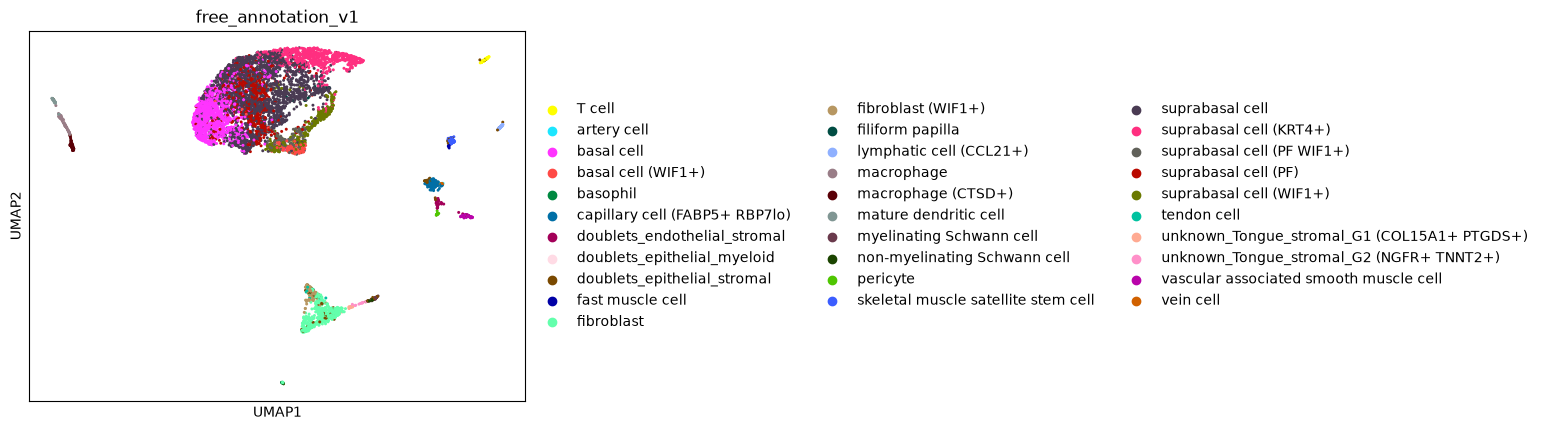

In [9]:
sc.pl.umap(adata, color = "free_annotation_v1")

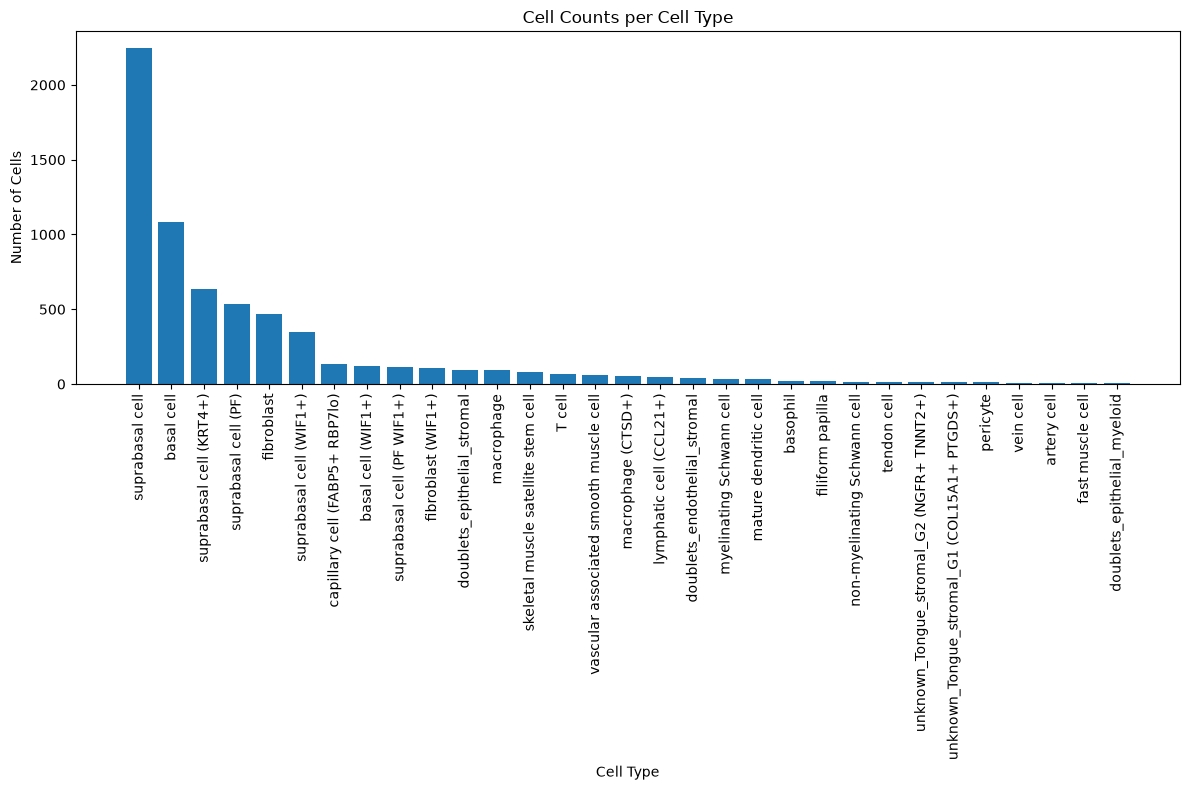

In [10]:
import matplotlib.pyplot as plt
cell_counts = adata.obs['free_annotation_v1'].value_counts()
plt.figure(figsize=(12, 8))
plt.bar(cell_counts.index, cell_counts.values)
plt.xlabel('Cell Type')
plt.ylabel('Number of Cells')
plt.title('Cell Counts per Cell Type')
plt.xticks(rotation=90)  
plt.tight_layout()
plt.show()

In [11]:
adata_original= (adata.copy())

In [12]:
adata_original = adata.copy()          
adata_rawcounts = adata.raw.to_adata()  

In [13]:
%whos

Variable          Type       Data/Info
--------------------------------------
ad                module     <module 'anndata' from 'c<...>s\\anndata\\__init__.py'>
adata             AnnData    AnnData object with n_obs<...>p'\n    layers: None (.X)
adata_original    AnnData    AnnData object with n_obs<...>p'\n    layers: None (.X)
adata_rawcounts   AnnData    AnnData object with n_obs<...>p'\n    layers: None (.X)
cell_counts       Series     Shape: (31,)
pd                module     <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
plt               module     <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
sc                module     <module 'scanpy' from 'c:<...>es\\scanpy\\__init__.py'>


In [14]:
for name in ['adata', 'adata_raw', 'adata_original']:
    try:
        obj = eval(name)
        print(name, '-> raw:', obj.raw is not None)
    except NameError:
        print(name, 'not defined')

adata -> raw: True
adata_raw not defined
adata_original -> raw: True


In [15]:
print(adata_original.X.max())

import scipy.sparse as sp
print(adata_original.X[:5, :5].toarray() if sp.issparse(adata_original.X) else adata_original.X[:5, :5])

8.382551
[[0.         0.43006662 0.         0.         0.        ]
 [1.0372958  1.0372958  0.6475159  0.         0.        ]
 [0.         0.5649496  0.         0.         0.        ]
 [1.7844557  0.21189335 0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]


In [16]:
adata.raw.X.data.max()

np.float32(300161.0)

In [17]:
adata.obs

,nCount_RNA,nFeature_RNA,possibly_contaminated_barcode_10x,assay_ontology_term_id,donor_id,age,sex_ontology_term_id,general_tissue,tissue_system,tissue_order,...,tissue_ontology_term_id,cell_type_ontology_term_id,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
L2_Tongue_10X_AAACCTGAGTAAGTAC,37219,4826,True,EFO:0009899,L2,10,PATO:0000383,Tongue,gastrointestinal,19,...,UBERON:0001723,CL:1001576,oral mucosa squamous cell,10x 3' v2,normal,female,tongue,na,post-juvenile adult stage,?@{znf)jlD
L2_Tongue_10X_AAACCTGCAGCTGTTA,21959,4578,True,EFO:0009899,L2,10,PATO:0000383,Tongue,gastrointestinal,19,...,UBERON:0001723,CL:1001576,oral mucosa squamous cell,10x 3' v2,normal,female,tongue,na,post-juvenile adult stage,JCK&3jHg57
L2_Tongue_10X_AAACCTGCAGGTCTCG,13169,2674,True,EFO:0009899,L2,10,PATO:0000383,Tongue,gastrointestinal,19,...,UBERON:0001723,CL:1001576,oral mucosa squamous cell,10x 3' v2,normal,female,tongue,na,post-juvenile adult stage,1w(I6d*N2E
L2_Tongue_10X_AAACGGGAGGACATTA,42370,5304,True,EFO:0009899,L2,10,PATO:0000383,Tongue,gastrointestinal,19,...,UBERON:0001723,CL:1001576,oral mucosa squamous cell,10x 3' v2,normal,female,tongue,na,post-juvenile adult stage,FI>m7`RW@W
L2_Tongue_10X_AAAGATGGTAACGCGA,16969,2785,True,EFO:0009899,L2,10,PATO:0000383,Tongue,gastrointestinal,19,...,UBERON:0001723,CL:1001576,oral mucosa squamous cell,10x 3' v2,normal,female,tongue,na,post-juvenile adult stage,G8Ql7ajS6;
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L4_Tongue_10X_TTTGTCACACGCTTTC,8264,2377,False,EFO:0009899,L4,11,PATO:0000384,Tongue,gastrointestinal,19,...,UBERON:0001723,CL:1001576,oral mucosa squamous cell,10x 3' v2,normal,male,tongue,na,post-juvenile adult stage,O=M3TqYcH4
L4_Tongue_10X_TTTGTCACACTTGGAT,3497,1178,False,EFO:0009899,L4,11,PATO:0000384,Tongue,gastrointestinal,19,...,UBERON:0001723,CL:1001576,oral mucosa squamous cell,10x 3' v2,normal,male,tongue,na,post-juvenile adult stage,b)iHFhgVn&
L4_Tongue_10X_TTTGTCACAGACAAAT,1169,730,False,EFO:0009899,L4,11,PATO:0000384,Tongue,gastrointestinal,19,...,UBERON:0001723,CL:0000057,fibroblast,10x 3' v2,normal,male,tongue,na,post-juvenile adult stage,TO#{k<}FHg
L4_Tongue_10X_TTTGTCAGTCGGGTCT,5393,1483,False,EFO:0009899,L4,11,PATO:0000384,Tongue,gastrointestinal,19,...,UBERON:0001723,CL:1001576,oral mucosa squamous cell,10x 3' v2,normal,male,tongue,na,post-juvenile adult stage,4?|3aFUIMO


In [18]:
import numpy as np

In [19]:
import anndata as ad


clean_adata = ad.AnnData(
    X=adata.X.copy(),
    obs=adata.obs[[]].copy(),  
)

print(clean_adata)

AnnData object with n_obs × n_vars = 6541 × 16400
    layers: None (.X)


## Quality control

In [20]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc

In [21]:

adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [22]:
adata.var["mt"] = adata.var["feature_name"].str.startswith("MT")
adata.var["ribo"] = adata.var["feature_name"].str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var["feature_name"].str.contains("^HB[^(P)]")

In [23]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

violin plots showing the number of genes expressed in the count matrix, total counts of cells and the percentage of counts in mitochondrial cells


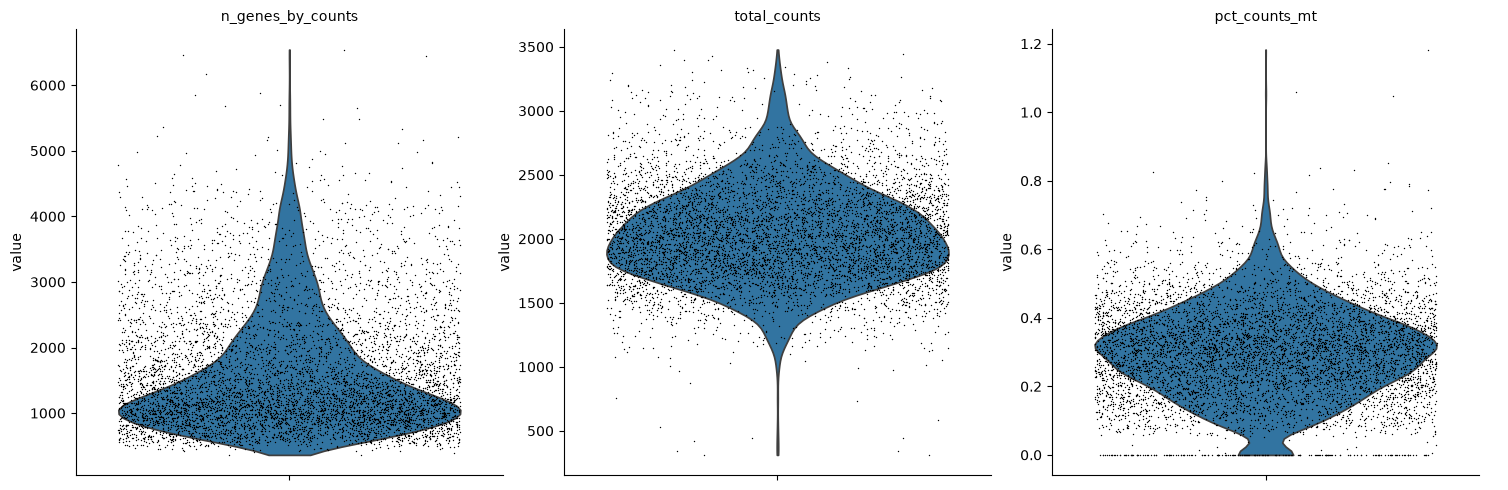

In [24]:
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True)

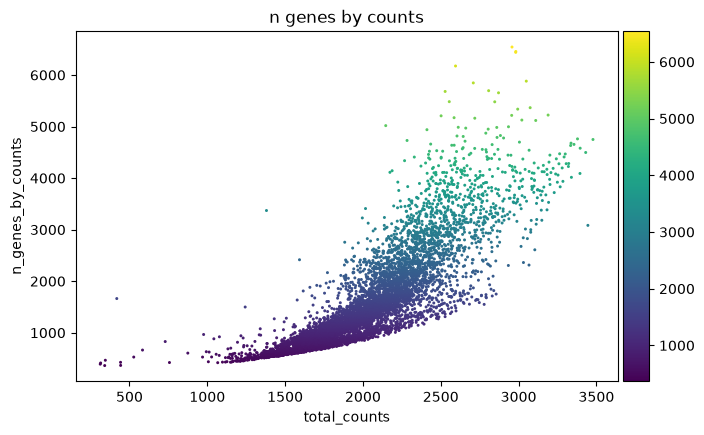

In [25]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="n_genes_by_counts")

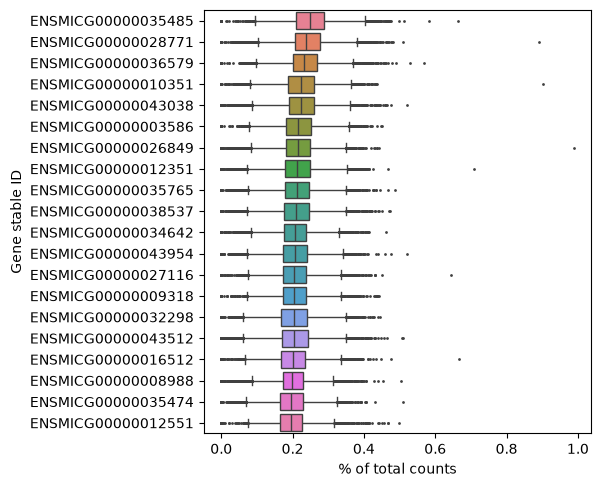

In [26]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [27]:
print(adata.obs.columns.tolist())

['nCount_RNA', 'nFeature_RNA', 'possibly_contaminated_barcode_10x', 'assay_ontology_term_id', 'donor_id', 'age', 'sex_ontology_term_id', 'general_tissue', 'tissue_system', 'tissue_order', 'subtissue', 'compartment_v1', 'cell_ontology_class_v1', 'free_annotation_v1', 'mix_hybrid', 'low_quality', 'dendrogram_annotation_number', 'Mimu_168', 'Mimu_W03', 'Mimu_W04', 'Mimu_180ps', 'Mimu_191', 'Mimu_202', 'Mimu_208', 'Mimu_218', 'Mimu_229ps', 'Mimu_239ps', 'Mimu_249', 'Mimu_DMA', 'Mimu_DMB', 'Mimu_DPA', 'Mimu_DPB', 'Mimu_DQA', 'Mimu_DQB', 'Mimu_DRA', 'Mimu_DRB', 'MHC_C_I', 'MHC_NC_I', 'MHC_all_II', 'nMimu_168', 'nMimu_W03', 'nMimu_W04', 'nMimu_180ps', 'nMimu_191', 'nMimu_202', 'nMimu_208', 'nMimu_218', 'nMimu_229ps', 'nMimu_239ps', 'nMimu_249', 'nMimu_DMA', 'nMimu_DMB', 'nMimu_DPA', 'nMimu_DPB', 'nMimu_DQA', 'nMimu_DQB', 'nMimu_DRA', 'nMimu_DRB', 'nMHC_C_I', 'nMHC_NC_I', 'nMHC_all_II', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id'

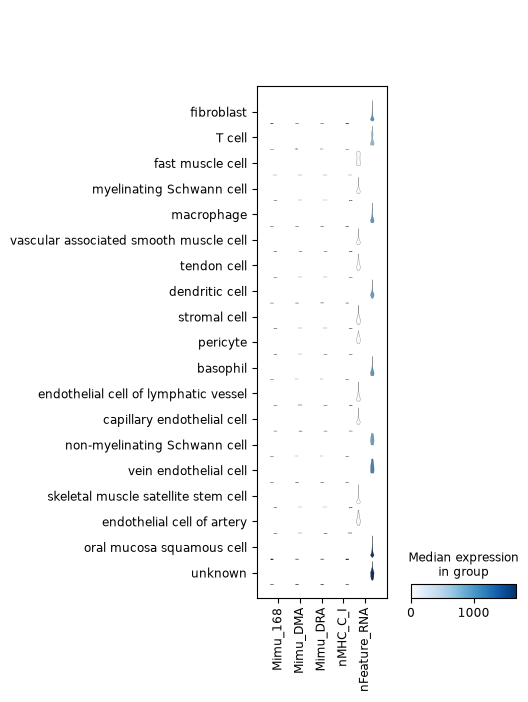

In [28]:
import scanpy as sc

sc.pl.stacked_violin(
    adata, 
    var_names=["Mimu_168", "Mimu_DMA", "Mimu_DRA", "nMHC_C_I", "nFeature_RNA"], 
    groupby="cell_type"
)

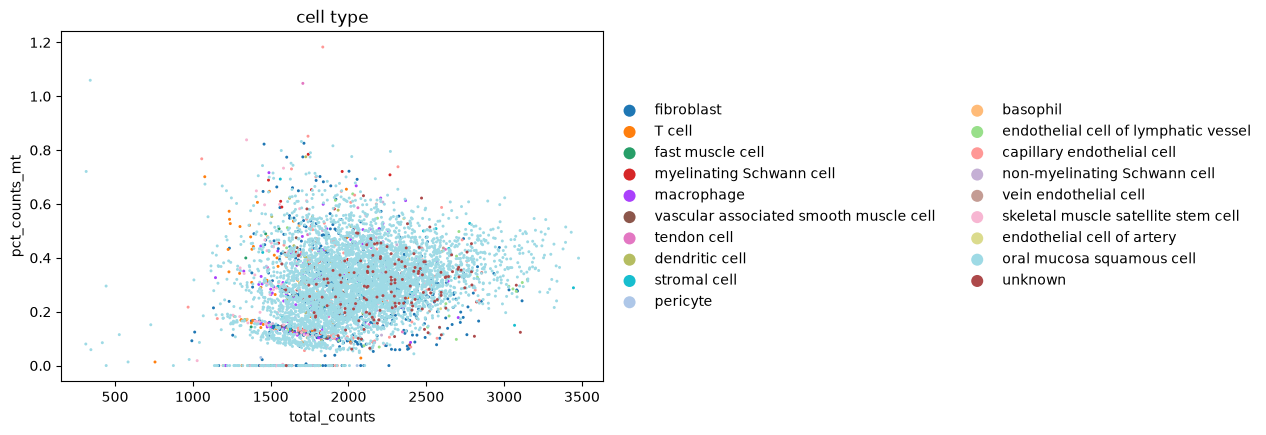

In [29]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", color="cell_type")

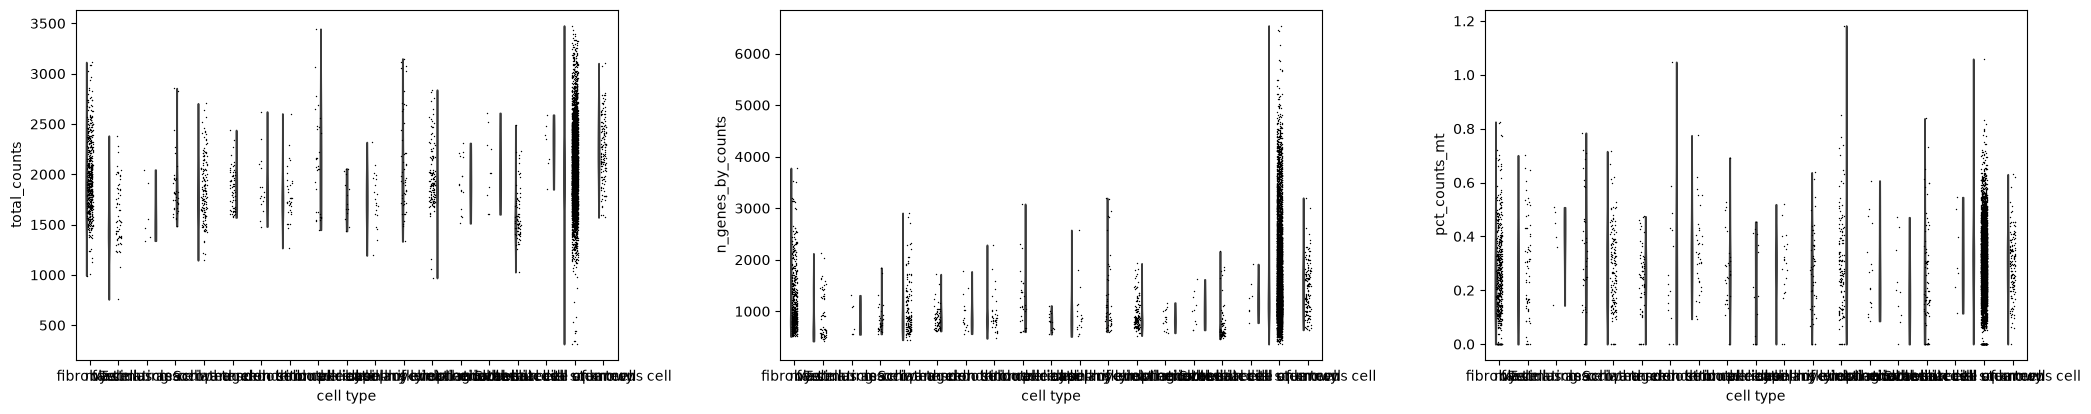

In [30]:
import scanpy as sc
sc.pl.violin(
    adata, 
    keys=["total_counts", "n_genes_by_counts", "pct_counts_mt"], 
    groupby="cell_type",  
    multi_panel=True
)

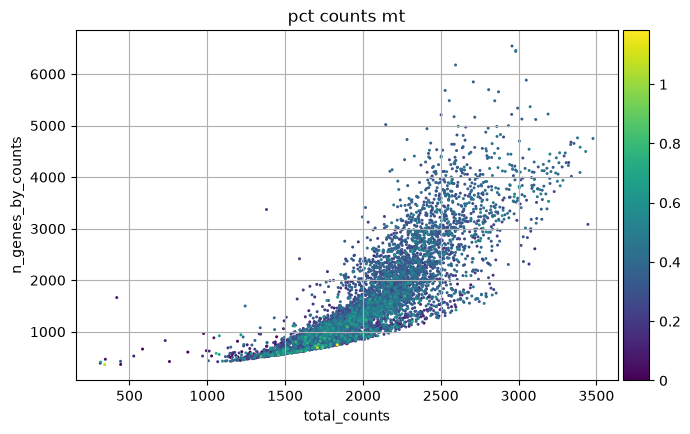

In [31]:
ax = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt", show=False)
ax.grid(True)
plt.show()


In [32]:
adata.layers

Layers with keys: None

In [33]:
# Check raw matrix max value vs total_counts
print("Matrix max value in X:", adata.X.max())
print("First 5 total_counts:", adata.obs['total_counts'].head())

Matrix max value in X: 8.382551
First 5 total_counts: L2_Tongue_10X_AAACCTGAGTAAGTAC    2607.708496
L2_Tongue_10X_AAACCTGCAGCTGTTA    2966.926025
L2_Tongue_10X_AAACCTGCAGGTCTCG    2126.233643
L2_Tongue_10X_AAACGGGAGGACATTA    2643.840088
L2_Tongue_10X_AAAGATGGTAACGCGA    2011.705200
Name: total_counts, dtype: float32


In [34]:
# Verify column summaries directly
print(adata.obs[['total_counts', 'n_genes_by_counts']].describe())

       total_counts  n_genes_by_counts
count   6541.000000        6541.000000
mean    2035.015869        1613.430821
std      376.886475         912.971637
min      312.143188         363.000000
25%     1773.920166         958.000000
50%     2007.762207        1325.000000
75%     2268.158203        2038.000000
max     3478.084473        6543.000000


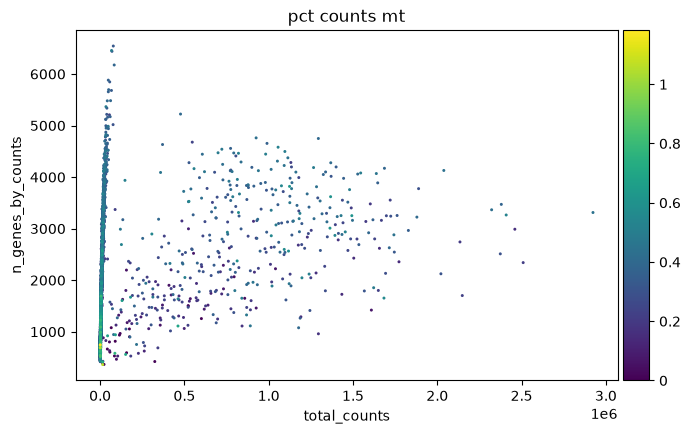

In [35]:
import scanpy as sc

# Recalculate metrics on raw counts if available
if adata.raw is not None:
    adata_raw = adata.raw.to_adata()
    sc.pp.calculate_qc_metrics(adata_raw, inplace=True)
    
    # Plot using the fresh recalculation
    sc.pl.scatter(adata_raw, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")
else:
    # Recalculate directly on current adata
    sc.pp.calculate_qc_metrics(adata, inplace=True)
    sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")

Begin to filter out cells such as those with too many mitochondria genes expressed. However this is very permissive as cells with those conditions could not be damaged.


In [36]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [37]:
adata.obs

,nCount_RNA,nFeature_RNA,possibly_contaminated_barcode_10x,assay_ontology_term_id,donor_id,age,sex_ontology_term_id,general_tissue,tissue_system,tissue_order,...,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_genes
L2_Tongue_10X_AAACCTGAGTAAGTAC,37219,4826,True,EFO:0009899,L2,10,PATO:0000383,Tongue,gastrointestinal,19,...,8.806005,2.282995,0.337691,269.045135,5.598589,10.317301,0.668044,0.511651,0.025618,4190
L2_Tongue_10X_AAACCTGCAGCTGTTA,21959,4578,True,EFO:0009899,L2,10,PATO:0000383,Tongue,gastrointestinal,19,...,8.535849,2.255058,0.287700,258.604553,5.559160,8.716246,1.037296,0.711623,0.034962,4028
L2_Tongue_10X_AAACCTGCAGGTCTCG,13169,2674,True,EFO:0009899,L2,10,PATO:0000383,Tongue,gastrointestinal,19,...,4.878397,1.771284,0.229438,279.947052,5.638166,13.166335,0.564950,0.447854,0.026570,2297
L2_Tongue_10X_AAACGGGAGGACATTA,42370,5304,True,EFO:0009899,L2,10,PATO:0000383,Tongue,gastrointestinal,19,...,9.547176,2.355858,0.361110,251.669724,5.532083,9.519098,1.351054,0.854864,0.051102,4591
L2_Tongue_10X_AAAGATGGTAACGCGA,16969,2785,True,EFO:0009899,L2,10,PATO:0000383,Tongue,gastrointestinal,19,...,5.207375,1.825738,0.258854,283.513824,5.650782,14.093210,0.000000,0.000000,0.000000,2426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L4_Tongue_10X_TTTGTCACACGCTTTC,8264,2377,False,EFO:0009899,L4,11,PATO:0000384,Tongue,gastrointestinal,19,...,5.561825,1.881269,0.218926,228.984711,5.438013,9.013340,2.572664,1.273311,0.101266,2131
L4_Tongue_10X_TTTGTCACACTTGGAT,3497,1178,False,EFO:0009899,L4,11,PATO:0000384,Tongue,gastrointestinal,19,...,6.752810,2.048055,0.371752,275.038940,5.620542,15.141298,0.000000,0.000000,0.000000,1053
L4_Tongue_10X_TTTGTCACAGACAAAT,1169,730,False,EFO:0009899,L4,11,PATO:0000384,Tongue,gastrointestinal,19,...,9.027973,2.305378,0.556925,202.338257,5.314871,12.482001,4.513987,1.707288,0.278462,646
L4_Tongue_10X_TTTGTCAGTCGGGTCT,5393,1483,False,EFO:0009899,L4,11,PATO:0000384,Tongue,gastrointestinal,19,...,7.341677,2.121264,0.387940,276.993652,5.627598,14.636573,1.048811,0.717260,0.055420,1303


In [38]:
adata.obs.columns

Index(['nCount_RNA', 'nFeature_RNA', 'possibly_contaminated_barcode_10x',
       'assay_ontology_term_id', 'donor_id', 'age', 'sex_ontology_term_id',
       'general_tissue', 'tissue_system', 'tissue_order', 'subtissue',
       'compartment_v1', 'cell_ontology_class_v1', 'free_annotation_v1',
       'mix_hybrid', 'low_quality', 'dendrogram_annotation_number', 'Mimu_168',
       'Mimu_W03', 'Mimu_W04', 'Mimu_180ps', 'Mimu_191', 'Mimu_202',
       'Mimu_208', 'Mimu_218', 'Mimu_229ps', 'Mimu_239ps', 'Mimu_249',
       'Mimu_DMA', 'Mimu_DMB', 'Mimu_DPA', 'Mimu_DPB', 'Mimu_DQA', 'Mimu_DQB',
       'Mimu_DRA', 'Mimu_DRB', 'MHC_C_I', 'MHC_NC_I', 'MHC_all_II',
       'nMimu_168', 'nMimu_W03', 'nMimu_W04', 'nMimu_180ps', 'nMimu_191',
       'nMimu_202', 'nMimu_208', 'nMimu_218', 'nMimu_229ps', 'nMimu_239ps',
       'nMimu_249', 'nMimu_DMA', 'nMimu_DMB', 'nMimu_DPA', 'nMimu_DPB',
       'nMimu_DQA', 'nMimu_DQB', 'nMimu_DRA', 'nMimu_DRB', 'nMHC_C_I',
       'nMHC_NC_I', 'nMHC_all_II', 'self_repor

## doublet detection

Scrublet predicts cell doublets using a nearest-neighbor classifier of observed transcriptomes and simulated doublets.

In [39]:
%pip install scrublet

Note: you may need to restart the kernel to use updated packages.


c:\Users\eok33\python_intro\.venv\Scripts\python.exe: No module named pip


In [40]:
sc.pp.scrublet(adata)

In [41]:
sc.pp.scrublet(adata, batch_key="donor_id")

In [42]:
pip install doubletdetection

Note: you may need to restart the kernel to use updated packages.


c:\Users\eok33\python_intro\.venv\Scripts\python.exe: No module named pip


In [43]:
import doubletdetection

In [44]:
# Check raw count locations
if hasattr(adata, 'raw') and adata.raw is not None:
    print("Raw matrix found in adata.raw!")
    print("Raw max value:", adata.raw.X.max())
elif 'counts' in adata.layers:
    print("Raw matrix found in adata.layers['counts']!")
    print("Counts max value:", adata.layers['counts'].max())
else:
    print("Checking if nCount_RNA in adata.obs holds original totals...")

Raw matrix found in adata.raw!
Raw max value: 300161.0


In [45]:
import scanpy as sc


sc.pp.scrublet(adata)


print(adata.obs["predicted_doublet"].value_counts())
print(f"\nDoublet score range: {adata.obs['doublet_score'].min():.3f} - {adata.obs['doublet_score'].max():.3f}")

sc.pl.violin(adata, "doublet_score")


n_before = adata.n_obs

adata = adata[adata.obs["predicted_doublet"] == False].copy()

n_after = adata.n_obs
print(f"\nCells before: {n_before}")
print(f"Cells after removing predicted doublets: {n_after}")
print(f"Removed: {n_before - n_after} predicted doublets")

predicted_doublet
False    6528
True       13
Name: count, dtype: int64

Doublet score range: 0.003 - 0.612


c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\plotting\_utils.py:393: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



Cells before: 6541
Cells after removing predicted doublets: 6528
Removed: 13 predicted doublets


this is lower than would be expected at only 0.2%. One reason for this could be because this is post QC which may have removed a large number of doublets.


## normalisation

In [46]:
adata.layers["counts"] = adata.X.copy()

In [47]:

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

## Feature selection

Only including the most informative genes

In [48]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="donor_id")


In [49]:
%matplotlib inline


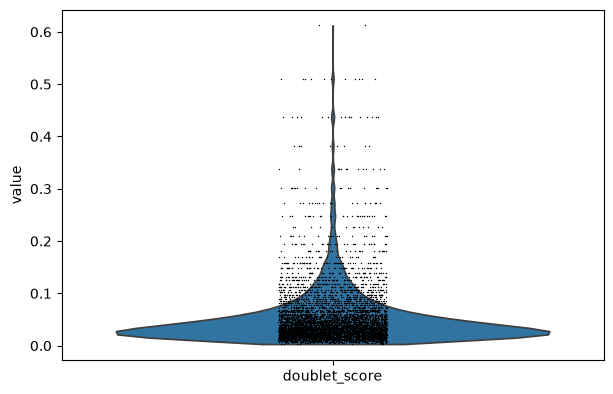

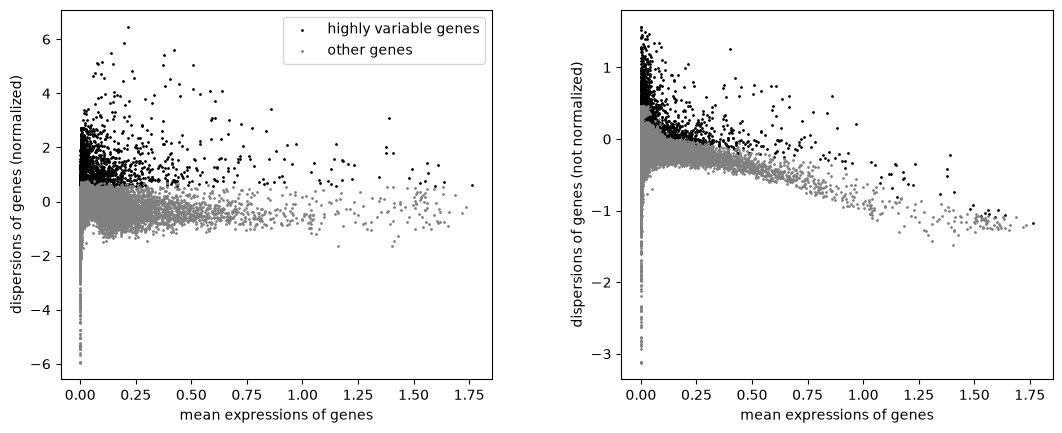

In [50]:
sc.pl.highly_variable_genes(adata)

## Dimensionality reduction

In [51]:
sc.tl.pca(adata)

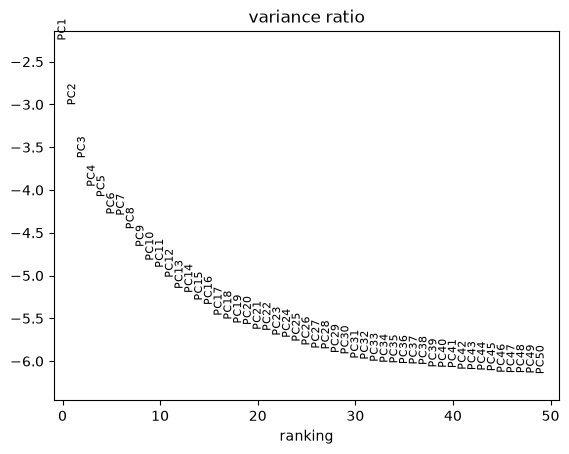

In [52]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

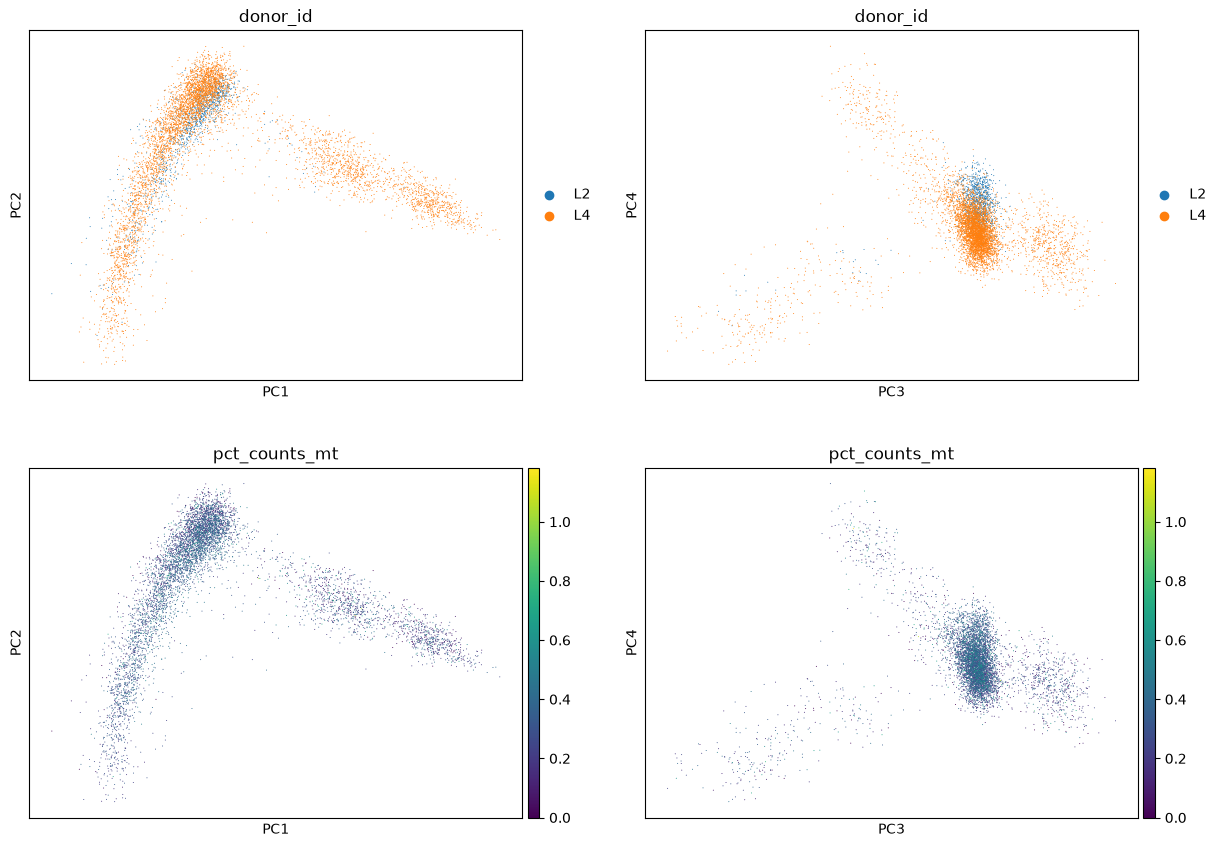

In [53]:
sc.pl.pca(
    adata,
    color=["donor_id", "donor_id", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

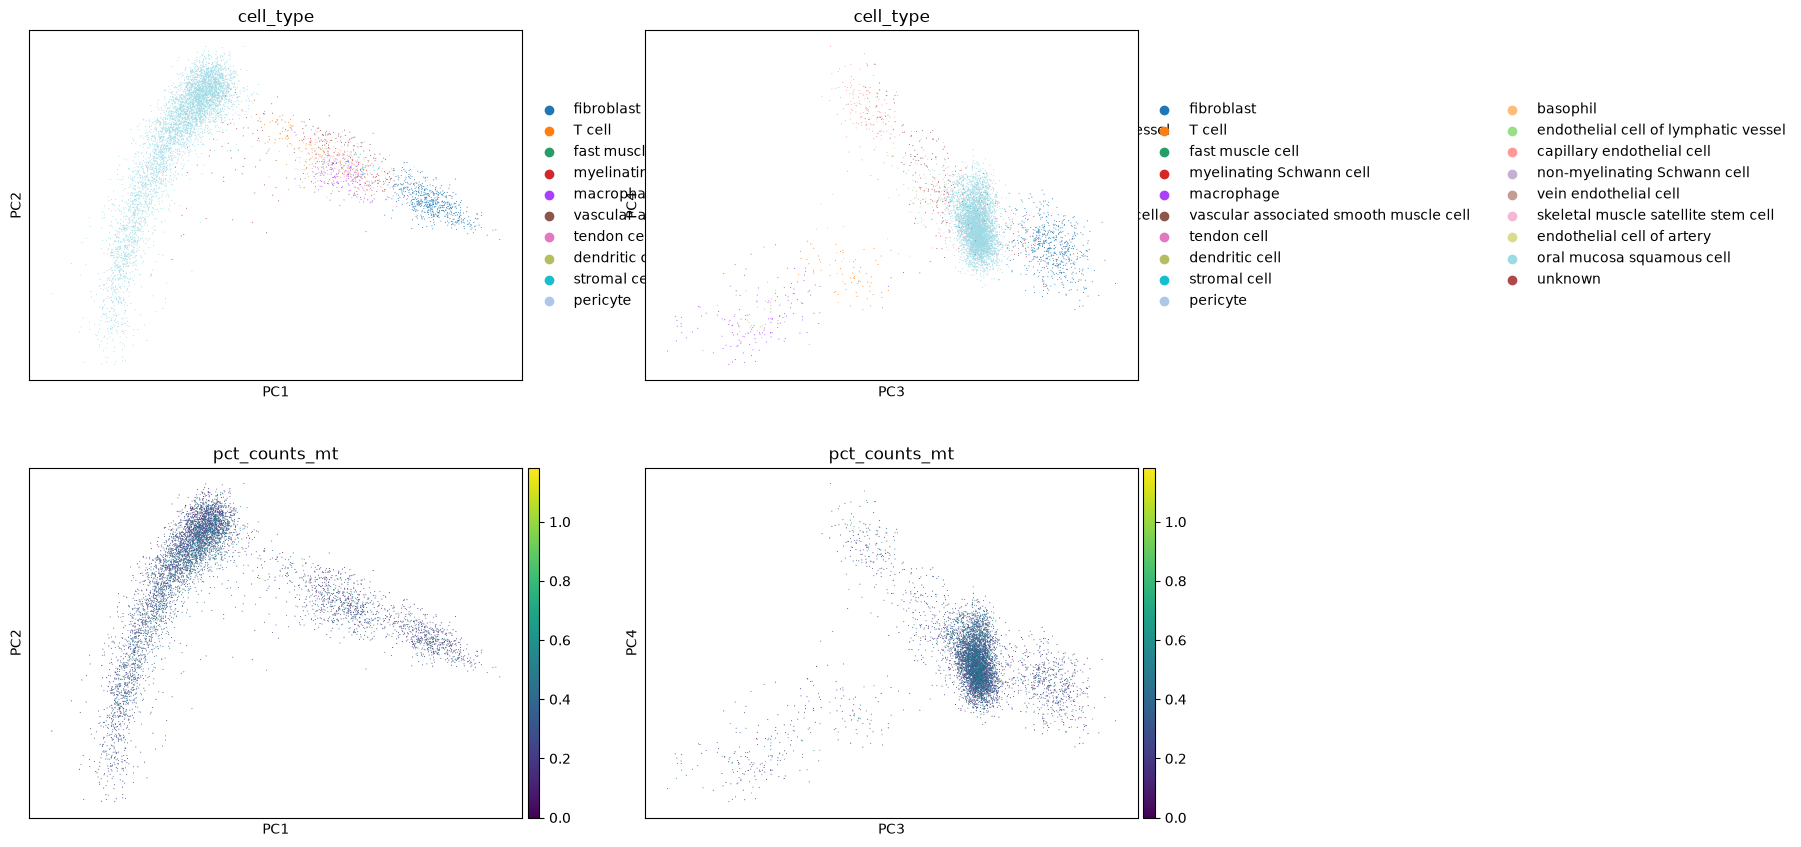

In [54]:
sc.pl.pca(
    adata,
    color=["cell_type", "cell_type", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [55]:
sc.pp.neighbors(adata)

In [56]:
sc.tl.umap(adata)

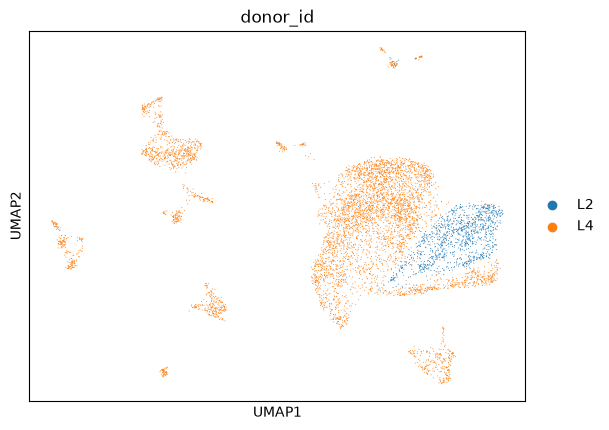

In [57]:
sc.pl.umap(
    adata,
    color="donor_id",
    size=2,
)

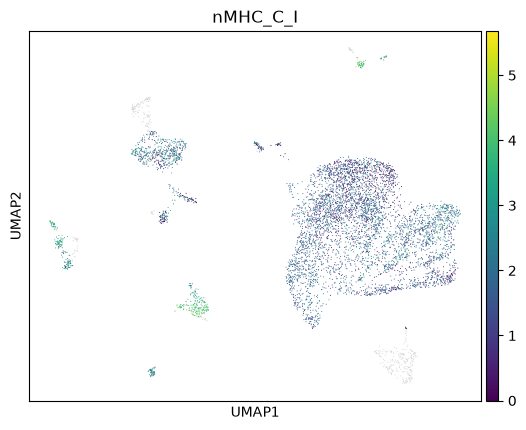

In [58]:
sc.pl.umap(
    adata,
    color="nMHC_C_I",
    size=2,
)

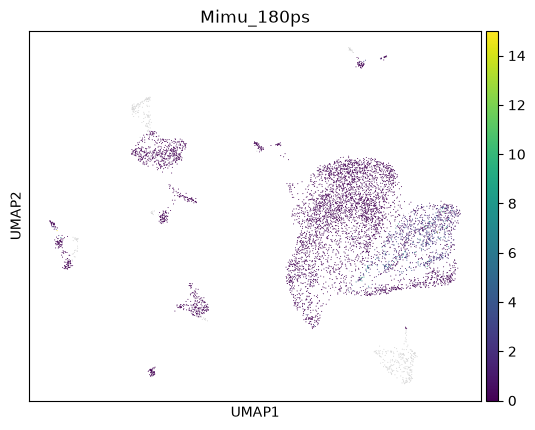

In [59]:
sc.pl.umap(
    adata,
    color="Mimu_180ps",
    size=2,
)

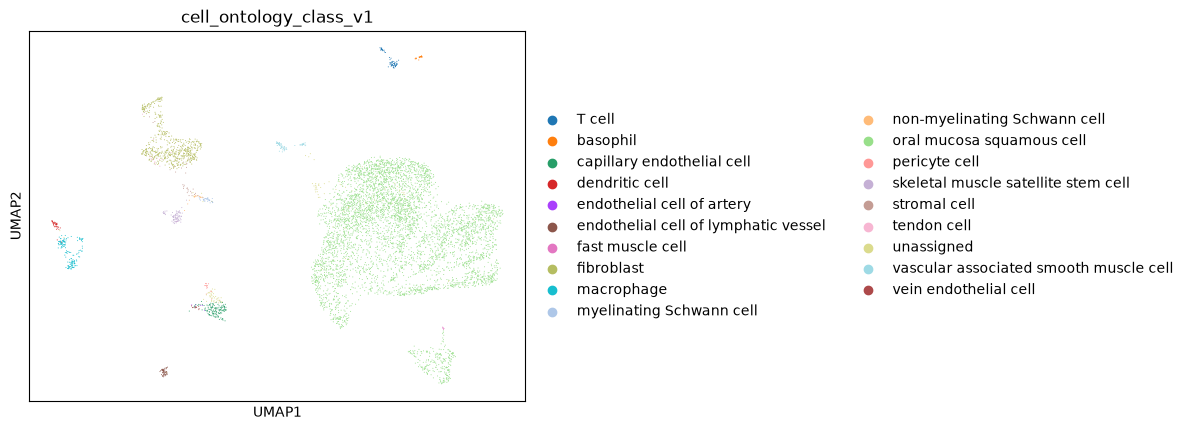

In [60]:
sc.pl.umap(
    adata,
    color="cell_ontology_class_v1",
    size=2,
)

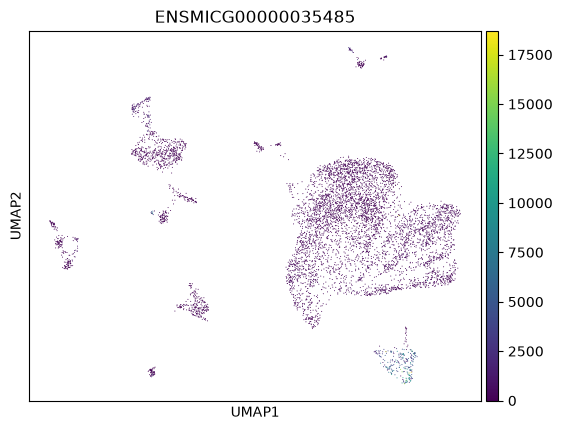

In [61]:
sc.pl.umap(
    adata,
    color="ENSMICG00000035485",
    size=2,
)

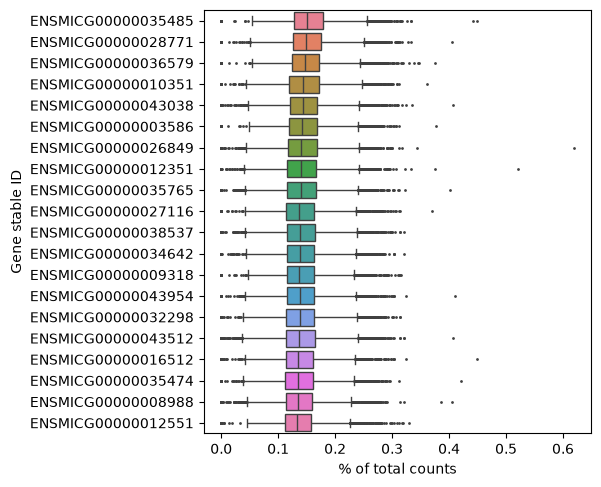

In [62]:
sc.pl.highest_expr_genes(adata, n_top=20)

## clustering


In [63]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

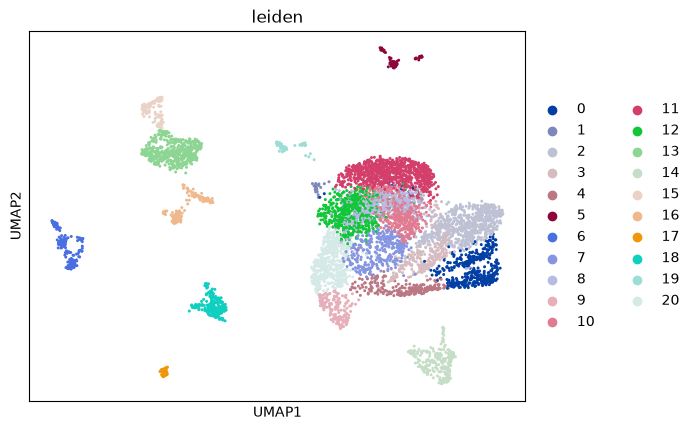

In [64]:
sc.pl.umap(adata, color=["leiden"])

## Re-assess quality control and cell filtering 


using umap I can visualise different qc metrics to re asssess filtering

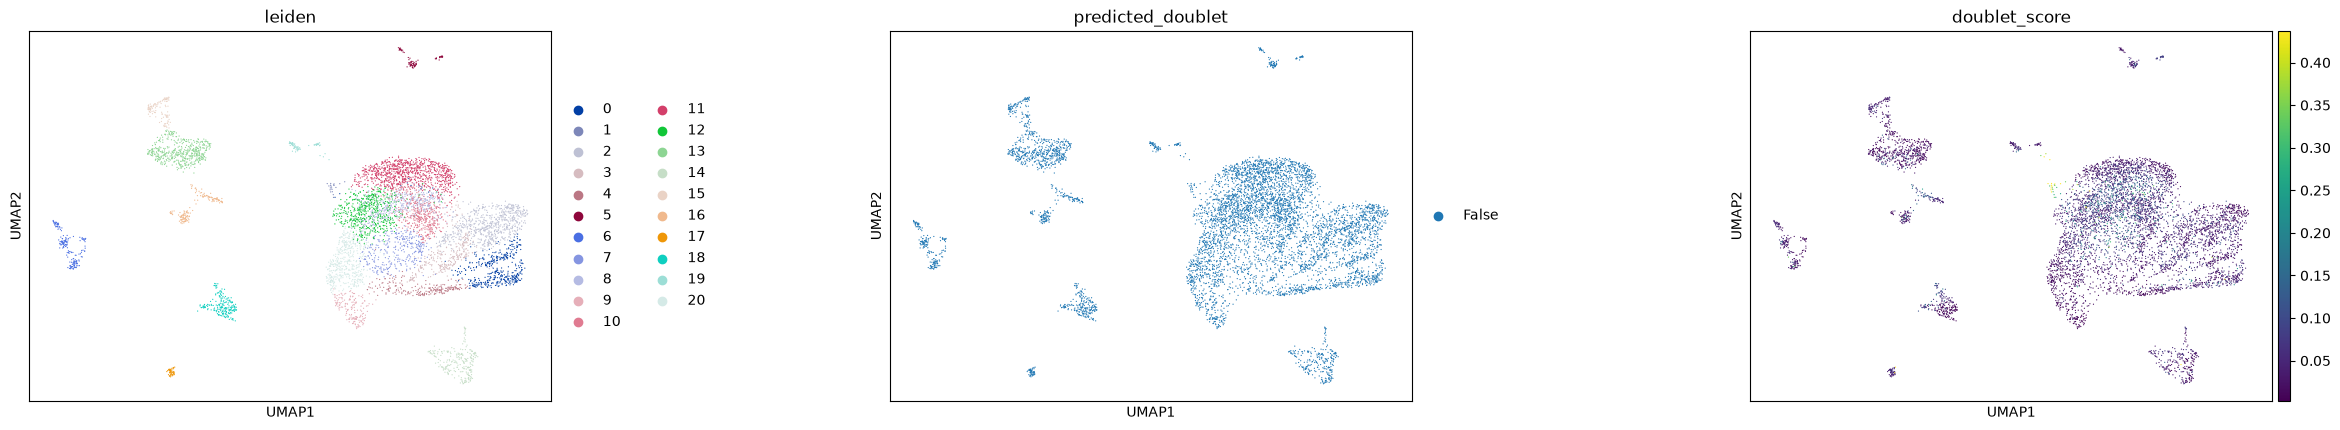

In [65]:
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

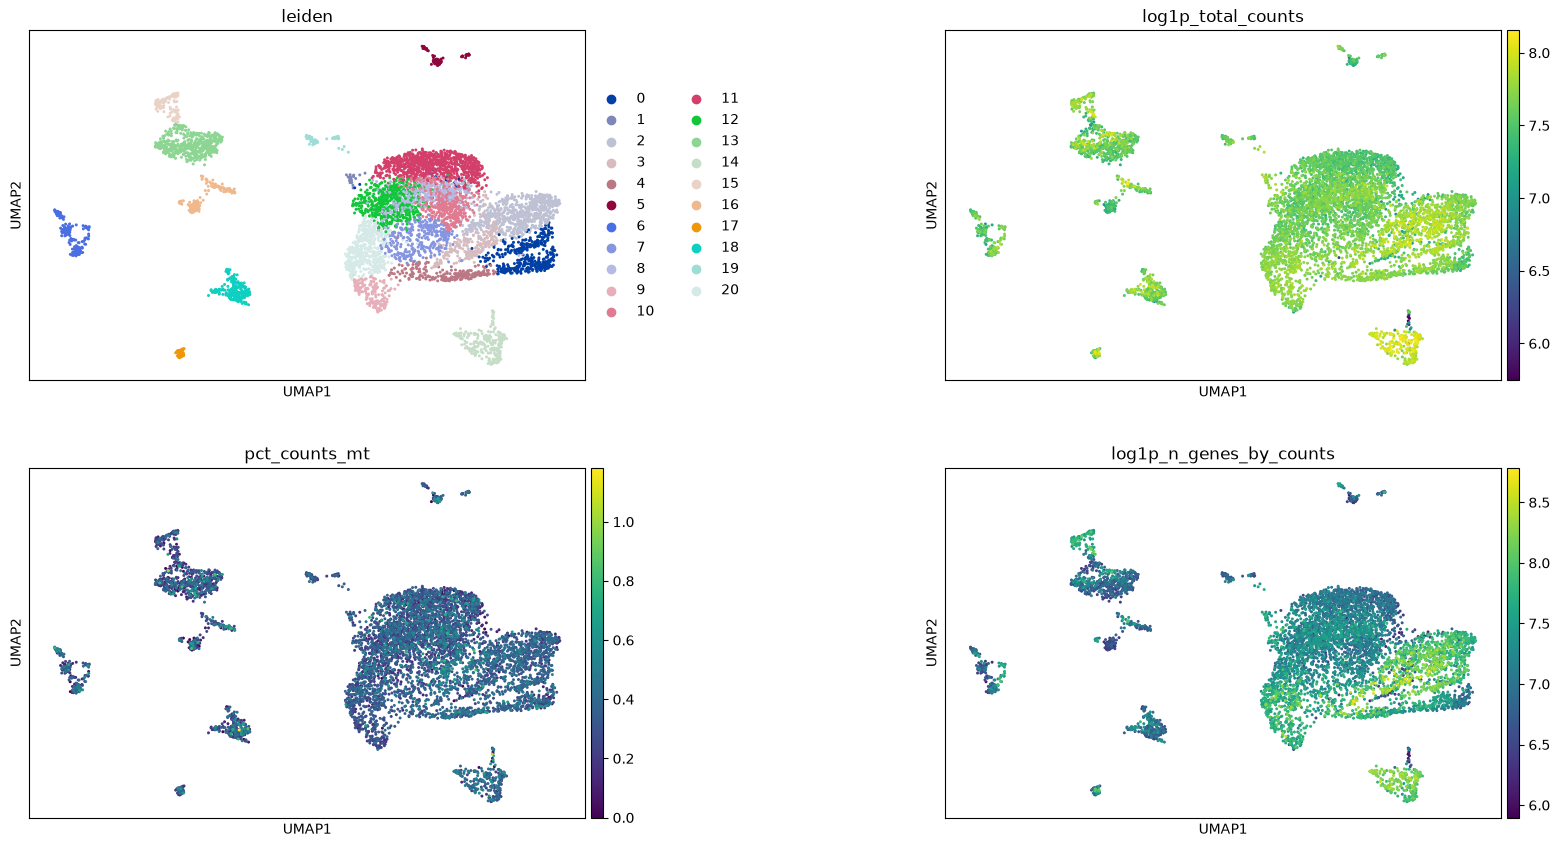

In [66]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

## Manual cell type annotation

In [67]:
for res in [0.02, 1.50, 3.0]:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

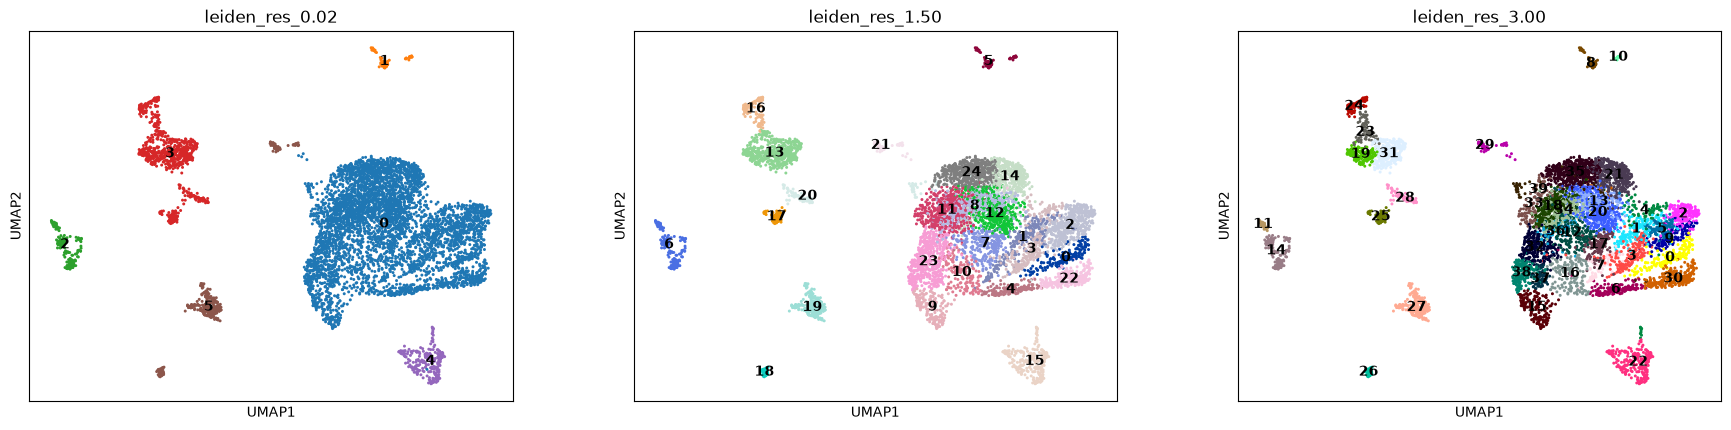

In [68]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_1.50", "leiden_res_3.00"],
    legend_loc="on data",
)

In [69]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
sc.tl.leiden(adata, resolution=1.0)

C:\Users\eok33\AppData\Local\Temp\ipykernel_34116\180540260.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1.0)


In [70]:

adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)  
sc.pp.log1p(adata)

## Marker gene set

In [71]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')

c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:631: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:633: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:631: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:633: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:631: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.

In [72]:
# See what cell types actually exist in your tongue data
print(adata.obs['free_annotation_v1'].value_counts())

free_annotation_v1
suprabasal cell                                2245
basal cell                                     1081
suprabasal cell (KRT4+)                         636
suprabasal cell (PF)                            536
fibroblast                                      467
suprabasal cell (WIF1+)                         349
capillary cell (FABP5+ RBP7lo)                  134
basal cell (WIF1+)                              118
suprabasal cell (PF WIF1+)                      112
fibroblast (WIF1+)                              108
macrophage                                       91
doublets_epithelial_stromal                      87
skeletal muscle satellite stem cell              79
T cell                                           64
vascular associated smooth muscle cell           62
macrophage (CTSD+)                               56
lymphatic cell (CCL21+)                          50
doublets_endothelial_stromal                     41
myelinating Schwann cell                     

In [73]:
sc.tl.rank_genes_groups(adata, groupby='free_annotation_v1', method='wilcoxon')

# Build a dict in the same style as your example
marker_genes = {}
for cell_type in adata.obs['free_annotation_v1'].cat.categories:
    top_genes = sc.get.rank_genes_groups_df(adata, group=cell_type).head(5)['names'].tolist()
    marker_genes[cell_type] = top_genes

print(marker_genes)

c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:630: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:631: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:630: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:633: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:630: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\eok33\python_intro\.venv\Lib\

{'T cell': ['ENSMICG00000047191', 'ENSMICG00000012861', 'ENSMICG00000042495', 'ENSMICG00000045758', 'ENSMICG00000000835'], 'artery cell': ['ENSMICG00000046540', 'ENSMICG00000002949', 'ENSMICG00000005670', 'ENSMICG00000012667', 'ENSMICG00000002820'], 'basal cell': ['ENSMICG00000012890', 'ENSMICG00000004394', 'ENSMICG00000011069', 'ENSMICG00000017125', 'ENSMICG00000003917'], 'basal cell (WIF1+)': ['ENSMICG00000028201', 'ENSMICG00000012061', 'ENSMICG00000002255', 'ENSMICG00000001196', 'ENSMICG00000012890'], 'basophil': ['ENSMICG00000014279', 'ENSMICG00000003842', 'ENSMICG00000046302', 'ENSMICG00000031785', 'ENSMICG00000006833'], 'capillary cell (FABP5+ RBP7lo)': ['ENSMICG00000012214', 'ENSMICG00000005187', 'ENSMICG00000017758', 'ENSMICG00000015488', 'ENSMICG00000048354'], 'doublets_endothelial_stromal': ['ENSMICG00000005187', 'ENSMICG00000012214', 'ENSMICG00000017758', 'ENSMICG00000041610', 'ENSMICG00000047232'], 'doublets_epithelial_myeloid': ['ENSMICG00000037215', 'ENSMICG00000000253', 

In [74]:
print(adata.X.max())
print(adata.X[:5, :5].toarray() if hasattr(adata.X, 'toarray') else adata.X[:5, :5])

4.3472376
[[0.         1.078456   0.         0.         0.        ]
 [1.5065944  1.5065944  1.2235936  0.         1.2235936 ]
 [0.         1.4329427  0.         0.         0.        ]
 [1.9096762  0.69398105 0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]


In [75]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [76]:
sc.tl.rank_genes_groups(adata, groupby='free_annotation_v1', method='wilcoxon')

c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:630: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:631: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:630: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:633: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:630: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\eok33\python_intro\.venv\Lib\

In [77]:
sc.tl.rank_genes_groups(adata, groupby='free_annotation_v1', method='wilcoxon', use_raw=False)

c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:609: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:612: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "pvals"] = pvals[global_indices]
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:622: PerformanceWarning: DataFrame is highly fragmented. 

In [78]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

sc.tl.rank_genes_groups(adata, groupby='free_annotation_v1', method='wilcoxon', use_raw=False)


In [79]:
markers_df = sc.get.rank_genes_groups_df(adata, group=None)
print(markers_df.head(20))

     group               names     scores  logfoldchanges         pvals  \
0   T cell  ENSMICG00000047191  11.845560       12.434692  2.268973e-32   
1   T cell  ENSMICG00000045393  11.771441        2.016415  5.478082e-32   
2   T cell  ENSMICG00000042495  11.714918        2.858909  1.068944e-31   
3   T cell  ENSMICG00000005040  11.561813        1.921077  6.433535e-31   
4   T cell  ENSMICG00000012861  11.435704        2.998735  2.772776e-30   
5   T cell  ENSMICG00000011578  11.318760        3.986532  1.059604e-29   
6   T cell  ENSMICG00000027653  10.973891        4.337866  5.102781e-28   
7   T cell  ENSMICG00000045758  10.751901       10.135768  5.805312e-27   
8   T cell  ENSMICG00000000835  10.703110        5.364650  9.841903e-27   
9   T cell  ENSMICG00000046302  10.542907        5.979928  5.477928e-26   
10  T cell  ENSMICG00000002037  10.256261        8.078807  1.109191e-24   
11  T cell  ENSMICG00000028911  10.064697        1.815722  7.913073e-24   
12  T cell  ENSMICG000000

In [80]:
marker_genes = {}
for cell_type in adata.obs['free_annotation_v1'].cat.categories:
    top_genes = sc.get.rank_genes_groups_df(adata, group=cell_type).head(5)['names'].tolist()
    marker_genes[cell_type] = top_genes

print(marker_genes)

{'T cell': ['ENSMICG00000047191', 'ENSMICG00000045393', 'ENSMICG00000042495', 'ENSMICG00000005040', 'ENSMICG00000012861'], 'artery cell': ['ENSMICG00000046540', 'ENSMICG00000002949', 'ENSMICG00000010097', 'ENSMICG00000005670', 'ENSMICG00000015240'], 'basal cell': ['ENSMICG00000012890', 'ENSMICG00000004394', 'ENSMICG00000011069', 'ENSMICG00000044563', 'ENSMICG00000029559'], 'basal cell (WIF1+)': ['ENSMICG00000028201', 'ENSMICG00000012061', 'ENSMICG00000002255', 'ENSMICG00000001196', 'ENSMICG00000001311'], 'basophil': ['ENSMICG00000014279', 'ENSMICG00000003842', 'ENSMICG00000046302', 'ENSMICG00000031785', 'ENSMICG00000006833'], 'capillary cell (FABP5+ RBP7lo)': ['ENSMICG00000012214', 'ENSMICG00000005187', 'ENSMICG00000045156', 'ENSMICG00000017758', 'ENSMICG00000015488'], 'doublets_endothelial_stromal': ['ENSMICG00000005187', 'ENSMICG00000017758', 'ENSMICG00000012214', 'ENSMICG00000041610', 'ENSMICG00000047232'], 'doublets_epithelial_myeloid': ['ENSMICG00000012499', 'ENSMICG00000027842', 

In [81]:
print(adata.var.columns.tolist())
print(adata.var.head())


['name', 'highly_variable', 'NCBI gene (formerly Entrezgene) ID', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection']
                      name  highly_variable  \
Gene stable ID                                
ENSMICG00000048996    RBP2             True   
ENSMICG00000049340   COPB2            False   
ENSMICG00000048994  MRPS22             True   
ENSMICG00000048990  PIK3CB            False   
ENSMICG00000048920    FAIM            False   

                   NCBI gene (formerly Entrezgene) ID  feature_is_filtered  \
Gene stable ID                                                               
ENSMICG00000048996                          105862656                False   
EN

c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:631: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:633: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:630: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:631: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:630: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\eok33\python_intro\.venv\Lib\site-packages\scanpy\

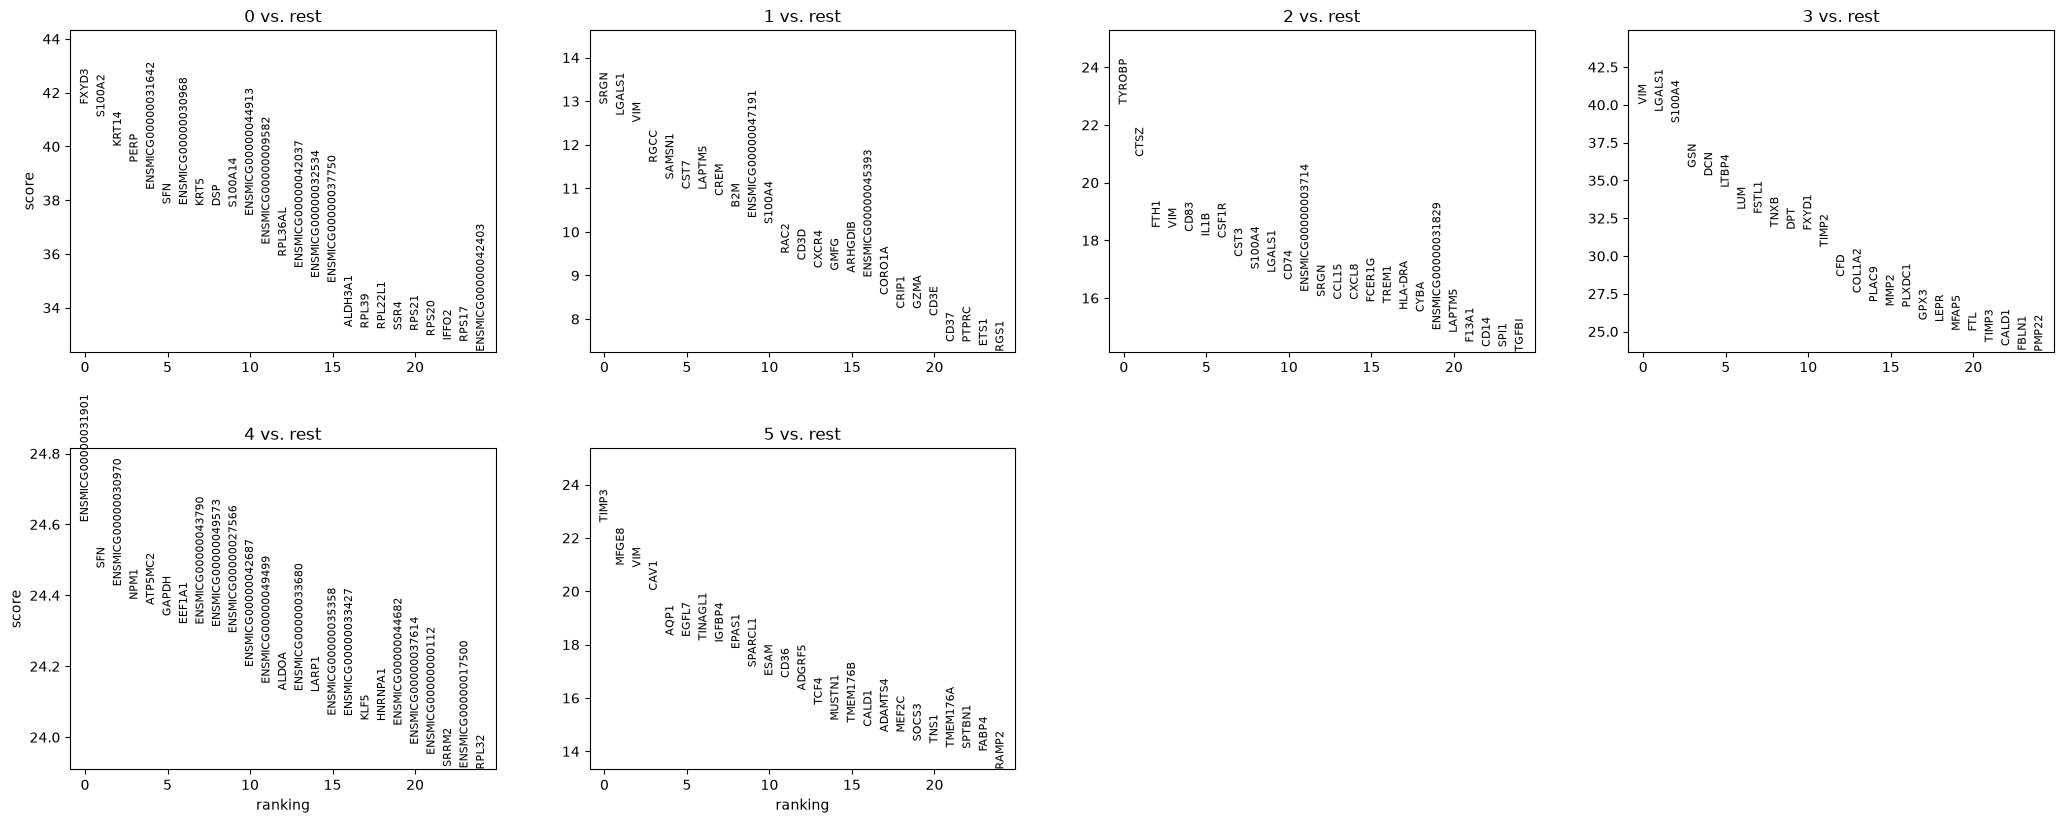

In [82]:
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.02", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, gene_symbols="feature_name")

In [83]:
adata.raw.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 10531992 stored elements and shape (6528, 16400)>

In [84]:
adata.raw.X.data.max()

np.float32(300161.0)

In [85]:
adata_original.X.max()

np.float32(8.382551)

In [86]:
adata.raw.var_names

Index(['ENSMICG00000048996', 'ENSMICG00000049340', 'ENSMICG00000048994',
       'ENSMICG00000049264', 'ENSMICG00000049580', 'ENSMICG00000049490',
       'ENSMICG00000048990', 'ENSMICG00000048920', 'ENSMICG00000048766',
       'ENSMICG00000049486',
       ...
       'ENSMICG00000045427', 'ENSMICG00000044411', 'ENSMICG00000030372',
       'ENSMICG00000045353', 'ENSMICG00000048119', 'ENSMICG00000042142',
       'ENSMICG00000045464', 'ENSMICG00000033168', 'ENSMICG00000035022',
       'ENSMICG00000028681'],
      dtype='str', name='Gene stable ID', length=16400)

In [87]:
adata.var

,name,highly_variable,NCBI gene (formerly Entrezgene) ID,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,mt,...,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection
Gene stable ID,,,,,,,,,,,,,,,,,,,,,
ENSMICG00000048996,RBP2,True,105862656,False,RBP2,NCBITaxon:30608,gene,757,protein_coding,False,...,0.277926,73.887785,2095.662598,7.648102,1708,0.263348,0.114871,1.420801,1,False
ENSMICG00000049340,COPB2,False,105862667,False,COPB2,NCBITaxon:30608,gene,2700,protein_coding,False,...,0.191590,78.046170,1381.286133,7.231494,1436,0.177954,-0.152695,-0.040659,0,False
ENSMICG00000048994,MRPS22,True,105862668,False,MRPS22,NCBITaxon:30608,gene,2023,protein_coding,False,...,0.070151,90.613056,475.332489,6.166116,614,0.076689,-0.034538,0.804739,1,False
ENSMICG00000048990,PIK3CB,False,105862660,False,PIK3CB,NCBITaxon:30608,gene,4916,protein_coding,False,...,0.079269,89.787494,539.603149,6.292686,668,0.069919,-0.073822,0.029670,0,False
ENSMICG00000048920,FAIM,False,105862665,False,FAIM,NCBITaxon:30608,gene,625,protein_coding,False,...,0.105636,87.295521,728.779419,6.592742,831,0.117555,-0.113905,-0.006327,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMICG00000045427,LOC105863196,False,105863196,False,ENSMICG00000045427,NCBITaxon:30608,gene,486,protein_coding,False,...,0.000782,99.434337,5.114868,1.810723,37,0.001471,-0.605792,-1.051211,0,False
ENSMICG00000044411,LOC105857536,True,105857536,False,CLEC12A,NCBITaxon:30608,gene,3605,protein_coding,False,...,0.007771,99.480202,51.024826,3.951721,34,0.005781,0.452999,1.218093,1,False
ENSMICG00000042142,LOC105880511,False,105880511,False,ENSMICG00000042142,NCBITaxon:30608,gene,542,protein_coding,False,...,1.383393,2.858890,19547.207031,9.880639,6354,1.343016,-1.118822,0.021901,0,False


In [88]:
print(adata.var.columns.tolist())
print(adata.raw.var.columns.tolist() if adata.raw is not None else "no adata.raw")

['name', 'highly_variable', 'NCBI gene (formerly Entrezgene) ID', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection']
['name', 'highly_variable', 'NCBI gene (formerly Entrezgene) ID', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type']


In [89]:
gene_symbol_col = 'name'  # adjust if different

all_requested_genes = [g for genes in marker_genes.items() for g in genes[1]]  # flatten your dict
available_symbols = set(adata.raw.var[gene_symbol_col]) if adata.raw is not None else set(adata.var[gene_symbol_col])

missing = [g for g in all_requested_genes if g not in available_symbols]
print("Missing genes:", missing)

Missing genes: ['ENSMICG00000047191', 'ENSMICG00000045393', 'ENSMICG00000042495', 'ENSMICG00000005040', 'ENSMICG00000012861', 'ENSMICG00000046540', 'ENSMICG00000002949', 'ENSMICG00000010097', 'ENSMICG00000005670', 'ENSMICG00000015240', 'ENSMICG00000012890', 'ENSMICG00000004394', 'ENSMICG00000011069', 'ENSMICG00000044563', 'ENSMICG00000029559', 'ENSMICG00000028201', 'ENSMICG00000012061', 'ENSMICG00000002255', 'ENSMICG00000001196', 'ENSMICG00000001311', 'ENSMICG00000014279', 'ENSMICG00000003842', 'ENSMICG00000046302', 'ENSMICG00000031785', 'ENSMICG00000006833', 'ENSMICG00000012214', 'ENSMICG00000005187', 'ENSMICG00000045156', 'ENSMICG00000017758', 'ENSMICG00000015488', 'ENSMICG00000005187', 'ENSMICG00000017758', 'ENSMICG00000012214', 'ENSMICG00000041610', 'ENSMICG00000047232', 'ENSMICG00000012499', 'ENSMICG00000027842', 'ENSMICG00000033022', 'ENSMICG00000008505', 'ENSMICG00000003459', 'ENSMICG00000011578', 'ENSMICG00000012214', 'ENSMICG00000011895', 'ENSMICG00000015488', 'ENSMICG00000045

encounted some issues where the gene name and the ensemble id kept getting mixed up, so following code fixes that

{'T cell': ['LOC105858493', 'LOC105855951', 'S100A4', 'B2M', 'LGALS1'], 'artery cell': ['SOX17', 'EPAS1', 'GPRC5A', 'ENG', 'CD2AP'], 'basal cell': ['LOC105872034', 'COL17A1', 'DST', 'FXYD3', 'S100A2'], 'basal cell (WIF1+)': ['DCN', 'WIF1', 'KRT18', 'LAMB3', 'FABP5'], 'basophil': ['LOC105866607', 'NRN1', 'SRGN', 'MS4A2', 'TPSAB1'], 'capillary cell (FABP5+ RBP7lo)': ['AQP1', 'LOC105879342', 'TIMP3', 'ADGRF5', 'MFGE8'], 'doublets_endothelial_stromal': ['LOC105879342', 'ADGRF5', 'AQP1', 'C5H11orf96', 'EGFL7'], 'doublets_epithelial_myeloid': ['TRPM2', 'NAPSA', 'CLEC4E', 'FPR1', 'KMO'], 'doublets_epithelial_stromal': ['VIM', 'AQP1', 'SPTBN1', 'MFGE8', 'TIMP3'], 'fast muscle cell': ['MYOZ1', 'LOC105882090', 'NRAP', 'PGAM2', 'ATP2A1'], 'fibroblast': ['DCN', 'DPT', 'LUM', 'GSN', 'LTBP4'], 'fibroblast (WIF1+)': ['LUM', 'DCN', 'COL1A2', 'CFD', 'SERPINA5'], 'filiform papilla': ['KRT36', 'SPINK6', 'LOC105885898', 'C15H10orf99', 'GLTP'], 'lymphatic cell (CCL21+)': ['MMRN1', 'CCL21', 'PLAC9', 'ECSCR'

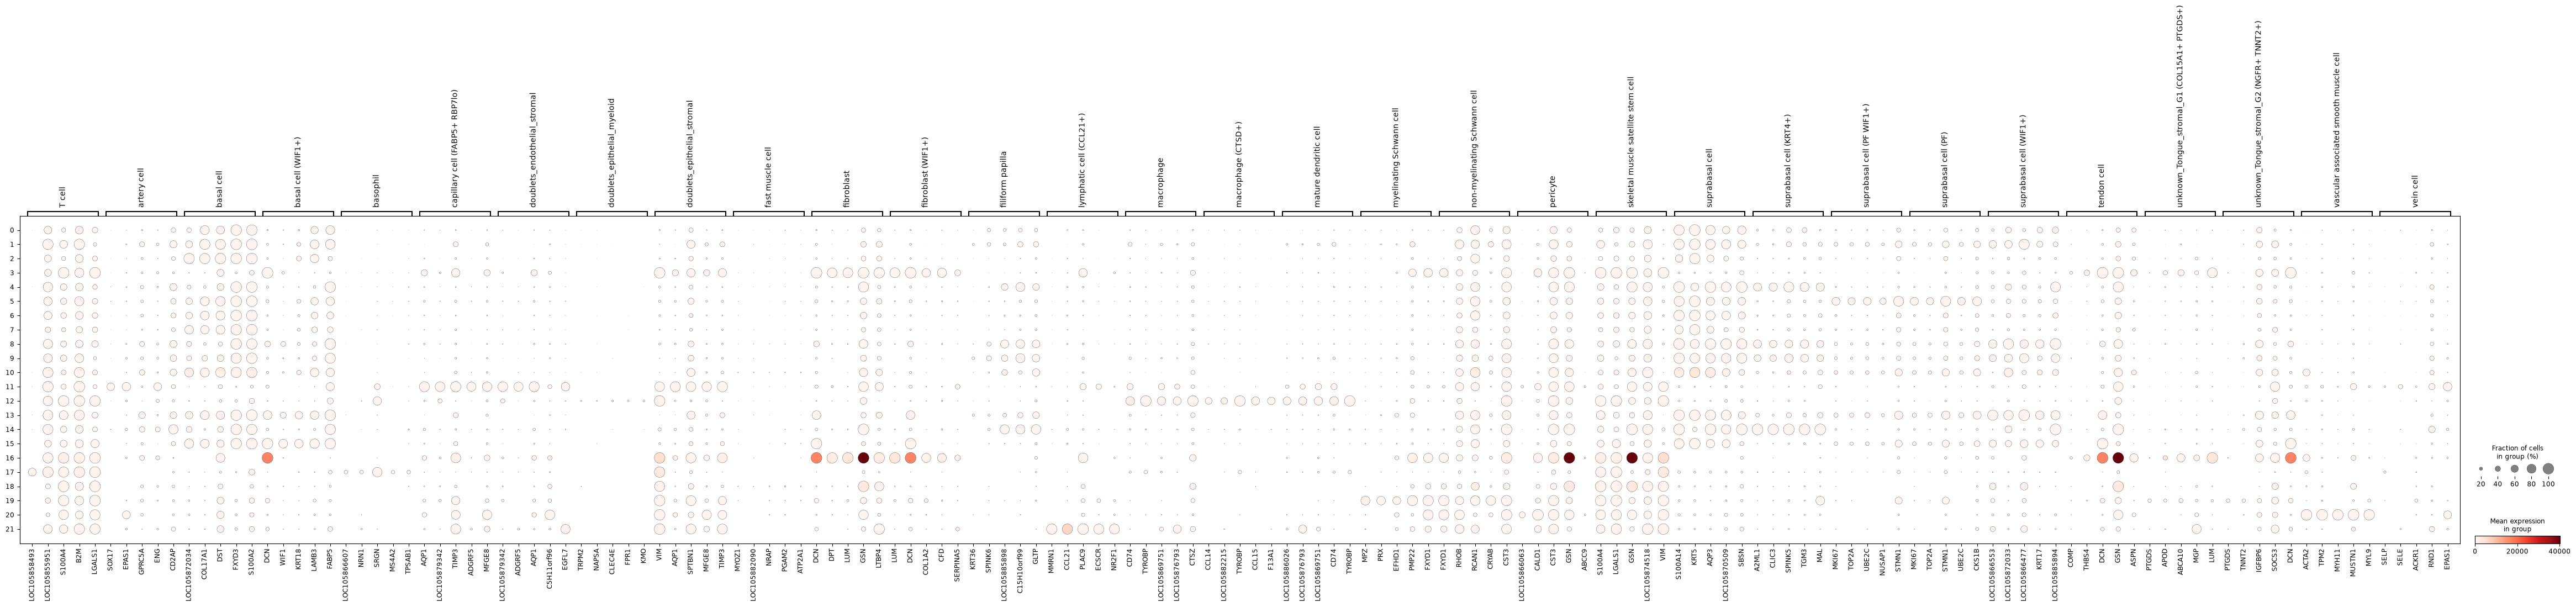

In [90]:

id_to_symbol = adata.var['name'].to_dict()

marker_genes_symbols = {
    cluster: [id_to_symbol.get(g, g) for g in genes]
    for cluster, genes in marker_genes.items()
}

print(marker_genes_symbols)  

sc.pl.dotplot(adata, marker_genes_symbols, groupby="leiden", gene_symbols="name")

Evidently, this boxplots shows very little mean gene expression so potentially I used the wrong marker gene set

In [91]:
print(adata_raw.X.max())

# Look at raw values
import scipy.sparse as sp
if sp.issparse(adata_raw.X):
    print(adata_raw.X[:5, :5].toarray())
else:
    print(adata_raw.X[:5, :5])

300161.0
[[ 0.  2.  0.  0.  0.]
 [ 4.  4.  2.  0.  0.]
 [ 0.  1.  0.  0.  0.]
 [21.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]


## celltypist

In [92]:
adata_2000 = ad.read_h5ad(r"C:\Users\eok33\python_intro\notebooks\data\Tongue.h5ad")

In [93]:
adata_2000.X.expm1().sum(axis = 1)

matrix([[8779.387],
        [8937.11 ],
        [8812.363],
        ...,
        [8930.711],
        [9004.265],
        [9206.859]], shape=(6541, 1), dtype=float32)

In [94]:
import scanpy as sc

In [95]:
import celltypist
from celltypist import models


c:\Users\eok33\python_intro\.venv\Lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [96]:
sc.pp.normalize_total(adata_raw, target_sum=1e4)
sc.pp.log1p(adata_raw)

In [97]:
print(adata_raw.var_names[:10])

Index(['ENSMICG00000048996', 'ENSMICG00000049340', 'ENSMICG00000048994',
       'ENSMICG00000049264', 'ENSMICG00000049580', 'ENSMICG00000049490',
       'ENSMICG00000048990', 'ENSMICG00000048920', 'ENSMICG00000048766',
       'ENSMICG00000049486'],
      dtype='str', name='Gene stable ID')


In [98]:
adata_2000.shape

(6541, 16400)

In [99]:
adata_2000.X.expm1().sum(axis = 1)

matrix([[8779.387],
        [8937.11 ],
        [8812.363],
        ...,
        [8930.711],
        [9004.265],
        [9206.859]], shape=(6541, 1), dtype=float32)

In [100]:
models.download_models(model='Immune_All_Low.pkl')
model = models.Model.load(model='Immune_All_Low.pkl')

📂 Storing models in C:\Users\eok33\.celltypist\data\models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)


In [101]:
models.download_models(force_update = True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in C:\Users\eok33\.celltypist\data\models
💾 Downloading model [1/61]: Immune_All_Low.pkl
💾 Downloading model [2/61]: Immune_All_High.pkl
💾 Downloading model [3/61]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/61]: Adult_Human_MTG.pkl
💾 Downloading model [6/61]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/61]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/61]: Adult_Human_Skin.pkl
💾 Downloading model [9/61]: Adult_Human_Vascular.pkl
💾 Downloading model [10/61]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/61]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/61]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/61]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/61]: Adult_cHSPCs_Illumina.pkl
💾 Downloading model [15/61]: Adult_cHSPCs_Ultima.pkl
💾 

In [102]:
'/home/jovyan/.celltypist/data/models'

'/home/jovyan/.celltypist/data/models'

In [103]:
model = models.Model.load(model = 'Adult_Human_Skin.pkl')

In [104]:
model

CellTypist model with 34 cell types and 3295 features
    date: 2023-09-22 18:13:10.902604
    details: cell types from human healthy adult skin
    source: https://doi.org/10.1126/science.aba6500
    version: v1
    cell types: DC1, DC2, ..., moDC
    features: ISG15, TNFRSF18, ..., MT-CYB

In [105]:
model.cell_types

array(['DC1', 'DC2', 'Differentiated_KC', 'F1', 'F2', 'F3', 'ILC1_3',
       'ILC1_NK', 'ILC2', 'Inf_mac', 'LC', 'LE1', 'LE2', 'Macro_1',
       'Macro_2', 'Mast_cell', 'Melanocyte', 'MigDC', 'Mono_mac', 'NK',
       'Pericyte_1', 'Pericyte_2', 'Plasma', 'Schwann_1', 'Schwann_2',
       'Tc', 'Th', 'Treg', 'Undifferentiated_KC', 'VE1', 'VE2', 'VE3',
       'migLC', 'moDC'], dtype=object)

In [106]:
print(adata_raw.shape) 

(6541, 16400)


In [107]:
adata_raw.var['ensembl_id'] = adata_raw.var_names  
adata_raw.var_names = adata_raw.var['name'].astype(str)
adata_raw.var_names_make_unique() 

print(adata_raw.var_names[:10])

Index(['RBP2', 'COPB2', 'MRPS22', 'LOC105862655', 'LOC105862654', 'FOXL2',
       'PIK3CB', 'FAIM', 'CEP70', 'ESYT3'],
      dtype='str', name='name')


In [108]:
sc.pp.pca(adata_raw, n_comps=50)
sc.pp.neighbors(adata_raw)

predictions = celltypist.annotate(adata_raw, model=model, majority_voting=True)
adata_raw.obs['celltypist_label'] = predictions.predicted_labels['predicted_labels']

🔬 Input data has 6541 cells and 16400 genes
🔗 Matching reference genes in the model
🧬 2633 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [109]:
import celltypist
from celltypist import models

models.download_models(model='Adult_Human_Skin.pkl')  
model = models.Model.load(model='Adult_Human_Skin.pkl')

predictions = celltypist.annotate(adata_raw, model=model, majority_voting=True)
adata_raw.obs['celltypist_label'] = predictions.predicted_labels['predicted_labels']

📂 Storing models in C:\Users\eok33\.celltypist\data\models
💾 Total models to download: 1
⏩ Skipping [1/1]: Adult_Human_Skin.pkl (file exists)
🔬 Input data has 6541 cells and 16400 genes
🔗 Matching reference genes in the model
🧬 2633 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [110]:
print(adata_raw.obs['celltypist_label'].value_counts())

celltypist_label
Undifferentiated_KC    2629
Differentiated_KC      2557
F2                      590
VE3                     112
Tc                       88
VE2                      76
Pericyte_2               64
Mono_mac                 59
Macro_2                  37
LE1                      32
LC                       27
Melanocyte               27
Treg                     25
DC2                      23
Th                       23
Macro_1                  21
MigDC                    20
migLC                    18
F1                       17
VE1                      17
Inf_mac                  16
DC1                      12
Mast_cell                 8
Pericyte_1                8
moDC                      7
F3                        6
LE2                       6
Schwann_1                 6
ILC1_3                    3
ILC1_NK                   2
ILC2                      2
NK                        2
Plasma                    1
Name: count, dtype: int64


In [111]:
pd.crosstab(adata_raw.obs['celltypist_label'], adata_raw.obs['free_annotation_v1'])

free_annotation_v1,T cell,artery cell,basal cell,basal cell (WIF1+),basophil,capillary cell (FABP5+ RBP7lo),doublets_endothelial_stromal,doublets_epithelial_myeloid,doublets_epithelial_stromal,fast muscle cell,...,suprabasal cell,suprabasal cell (KRT4+),suprabasal cell (PF WIF1+),suprabasal cell (PF),suprabasal cell (WIF1+),tendon cell,unknown_Tongue_stromal_G1 (COL15A1+ PTGDS+),unknown_Tongue_stromal_G2 (NGFR+ TNNT2+),vascular associated smooth muscle cell,vein cell
celltypist_label,,,,,,,,,,,,,,,,,,,,,
DC1,0,0,0,0,0,0,2,0,2,0,...,1,0,0,0,0,0,0,0,0,0
DC2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Differentiated_KC,2,0,135,23,1,9,1,1,27,1,...,1146,621,55,225,241,0,0,0,0,1
F1,0,1,0,0,0,2,0,0,1,1,...,1,0,0,1,0,0,0,0,0,0
F2,2,0,0,0,1,1,3,0,18,0,...,0,0,0,0,0,13,10,10,0,0
F3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ILC1_3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
ILC1_NK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ILC2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print(adata.var.columns.tolist())  
print(adata.var_names[:5])         

['name', 'highly_variable', 'NCBI gene (formerly Entrezgene) ID', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection']
Index(['ENSMICG00000048996', 'ENSMICG00000049340', 'ENSMICG00000048994',
       'ENSMICG00000048990', 'ENSMICG00000048920'],
      dtype='str', name='Gene stable ID')


In [ ]:
adata.var['ensembl_id'] = adata.var_names  
adata.var_names = adata.var['name'].astype(str)
adata.var_names_make_unique()

print(adata.var_names[:10])  

Index(['RBP2', 'COPB2', 'MRPS22', 'PIK3CB', 'FAIM', 'CEP70', 'ESYT3', 'MRAS',
       'ARMC8', 'DBR1'],
      dtype='str', name='name')


In [114]:
from celltypist import models

models.download_models(model='Adult_Human_Skin.pkl')
model = models.Model.load(model='Adult_Human_Skin.pkl')

predictions = celltypist.annotate(adata, model=model, majority_voting=True)
adata.obs['celltypist_skin_label'] = predictions.predicted_labels['predicted_labels']

📂 Storing models in C:\Users\eok33\.celltypist\data\models
💾 Total models to download: 1
⏩ Skipping [1/1]: Adult_Human_Skin.pkl (file exists)
🔬 Input data has 6528 cells and 14456 genes
🔗 Matching reference genes in the model
🧬 2572 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [115]:
predictions = celltypist.annotate(adata, model = 'Adult_Human_Skin.pkl', majority_voting = True)

🔬 Input data has 6528 cells and 14456 genes
🔗 Matching reference genes in the model
🧬 2572 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [116]:
adata = predictions.to_adata()

In [117]:
immune_types = ['T cell', 'macrophage', 'macrophage (CTSD+)', 'mature dendritic cell', 'basophil']
immune_subset = adata_raw.obs[adata_raw.obs['free_annotation_v1'].isin(immune_types)]

pd.crosstab(immune_subset['celltypist_label'], immune_subset['free_annotation_v1'])

free_annotation_v1,T cell,basophil,macrophage,macrophage (CTSD+),mature dendritic cell
celltypist_label,,,,,
DC1,0,0,1,2,0
DC2,0,0,6,4,7
Differentiated_KC,2,1,12,13,0
F1,0,0,0,1,0
F2,2,1,2,1,0
F3,0,0,1,0,0
ILC1_3,0,0,0,1,0
ILC1_NK,0,0,1,0,1
ILC2,0,0,0,0,1


In [118]:
sc.tl.umap(adata)

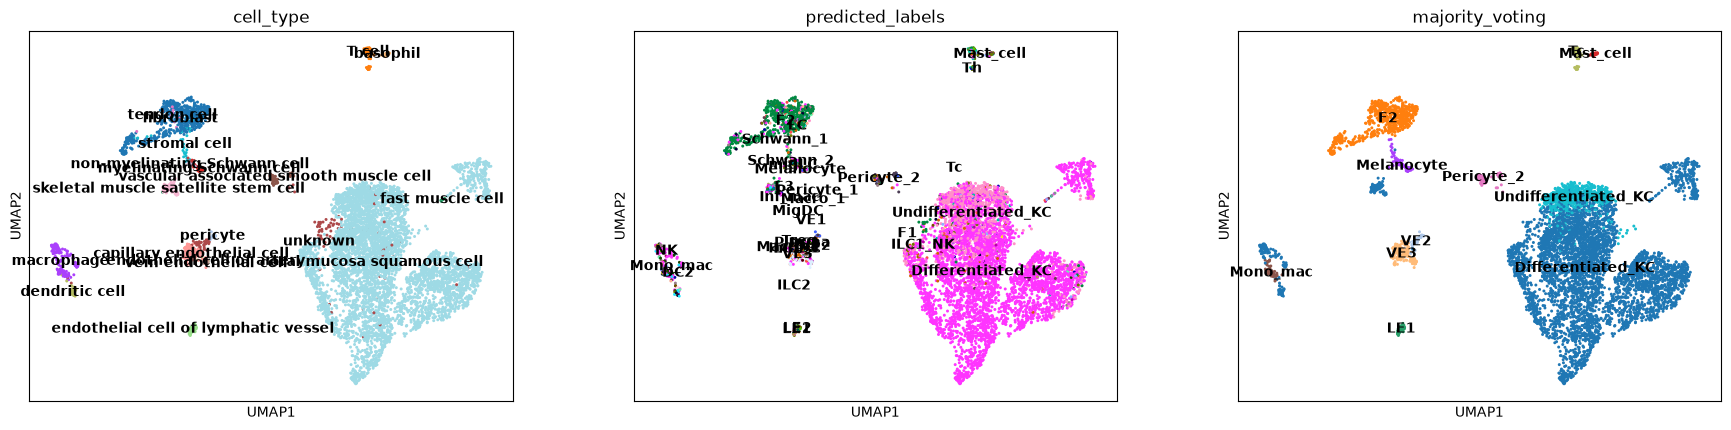

In [119]:
sc.pl.umap(adata, color = ['cell_type', 
'predicted_labels', 'majority_voting'], legend_loc = 'on data')

In [120]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
L2_Tongue_10X_AAACCTGAGTAAGTAC,Differentiated_KC,0,Differentiated_KC
L2_Tongue_10X_AAACCTGCAGCTGTTA,Differentiated_KC,1,Differentiated_KC
L2_Tongue_10X_AAACCTGCAGGTCTCG,Differentiated_KC,2,Differentiated_KC
L2_Tongue_10X_AAACGGGAGGACATTA,Differentiated_KC,4,Differentiated_KC
L2_Tongue_10X_AAAGATGGTAACGCGA,Differentiated_KC,3,Differentiated_KC
...,...,...,...
L4_Tongue_10X_TTTGTCACACGCTTTC,Differentiated_KC,83,Differentiated_KC
L4_Tongue_10X_TTTGTCACACTTGGAT,Undifferentiated_KC,63,Undifferentiated_KC
L4_Tongue_10X_TTTGTCACAGACAAAT,Differentiated_KC,61,F2
L4_Tongue_10X_TTTGTCAGTCGGGTCT,Differentiated_KC,96,Undifferentiated_KC


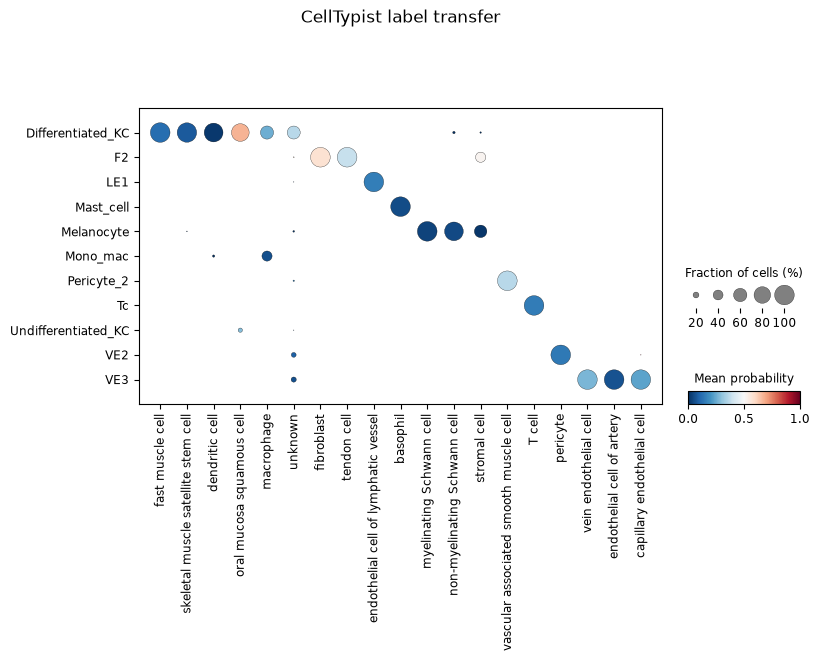

In [121]:
celltypist.dotplot(predictions, use_as_reference = 'cell_type', use_as_prediction = 'majority_voting')


This box plot shows very low probability. This could be because the cell typist models uses human data so will differ to a lemur mouse. furthermore, the data that I used was from the tongue which has little cells which correlate to the cell typist model

In [133]:
print(adata_original.obs.columns.tolist())
print(adata_original.var.columns.tolist())

['nCount_RNA', 'nFeature_RNA', 'possibly_contaminated_barcode_10x', 'assay_ontology_term_id', 'donor_id', 'age', 'sex_ontology_term_id', 'general_tissue', 'tissue_system', 'tissue_order', 'subtissue', 'compartment_v1', 'cell_ontology_class_v1', 'free_annotation_v1', 'mix_hybrid', 'low_quality', 'dendrogram_annotation_number', 'Mimu_168', 'Mimu_W03', 'Mimu_W04', 'Mimu_180ps', 'Mimu_191', 'Mimu_202', 'Mimu_208', 'Mimu_218', 'Mimu_229ps', 'Mimu_239ps', 'Mimu_249', 'Mimu_DMA', 'Mimu_DMB', 'Mimu_DPA', 'Mimu_DPB', 'Mimu_DQA', 'Mimu_DQB', 'Mimu_DRA', 'Mimu_DRB', 'MHC_C_I', 'MHC_NC_I', 'MHC_all_II', 'nMimu_168', 'nMimu_W03', 'nMimu_W04', 'nMimu_180ps', 'nMimu_191', 'nMimu_202', 'nMimu_208', 'nMimu_218', 'nMimu_229ps', 'nMimu_239ps', 'nMimu_249', 'nMimu_DMA', 'nMimu_DMB', 'nMimu_DPA', 'nMimu_DPB', 'nMimu_DQA', 'nMimu_DQB', 'nMimu_DRA', 'nMimu_DRB', 'nMHC_C_I', 'nMHC_NC_I', 'nMHC_all_II', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id'

In [ ]:
import anndata as ad
import numpy as np

list_of_metadata_columns = [
    "donor_id",
    "tissue",
    "sex",
    "age",
    "cell_type",
    "disease",       
]

list_of_gene_metadata_columns = [
    "name",       
    "feature_type",
]


X_raw = adata_original.raw.X if adata_original.raw is not None else adata_original.X

adata_new = ad.AnnData(
    X=X_raw.copy(),
    obs=adata_original.obs[list_of_metadata_columns].copy(),
    var=adata_original.var[list_of_gene_metadata_columns].copy()
)

In [ ]:
import anndata as ad
import numpy as np



X_raw = adata_original.raw.X if adata_original.raw is not None else adata_original.X

adata_new = ad.AnnData(
    X = X_raw.copy(),
    obs = adata_original.obs[list_of_metadata_columns].copy(),
    var = adata_original.var[list_of_gene_metadata_columns].copy()
)


## input project 2 into 1

Here, I redid the cell typist to attempt to fix some errors in the first attempt

adata.X.max(): 8.382551
adata.raw is None? False
adata.raw.X.max(): 300161.0
300161.0
['nCount_RNA', 'nFeature_RNA', 'possibly_contaminated_barcode_10x', 'assay_ontology_term_id', 'donor_id', 'age', 'sex_ontology_term_id', 'general_tissue', 'tissue_system', 'tissue_order', 'subtissue', 'compartment_v1', 'cell_ontology_class_v1', 'free_annotation_v1', 'mix_hybrid', 'low_quality', 'dendrogram_annotation_number', 'Mimu_168', 'Mimu_W03', 'Mimu_W04', 'Mimu_180ps', 'Mimu_191', 'Mimu_202', 'Mimu_208', 'Mimu_218', 'Mimu_229ps', 'Mimu_239ps', 'Mimu_249', 'Mimu_DMA', 'Mimu_DMB', 'Mimu_DPA', 'Mimu_DPB', 'Mimu_DQA', 'Mimu_DQB', 'Mimu_DRA', 'Mimu_DRB', 'MHC_C_I', 'MHC_NC_I', 'MHC_all_II', 'nMimu_168', 'nMimu_W03', 'nMimu_W04', 'nMimu_180ps', 'nMimu_191', 'nMimu_202', 'nMimu_208', 'nMimu_218', 'nMimu_229ps', 'nMimu_239ps', 'nMimu_249', 'nMimu_DMA', 'nMimu_DMB', 'nMimu_DPA', 'nMimu_DPB', 'nMimu_DQA', 'nMimu_DQB', 'nMimu_DRA', 'nMimu_DRB', 'nMHC_C_I', 'nMHC_NC_I', 'nMHC_all_II', 'self_reported_ethnici

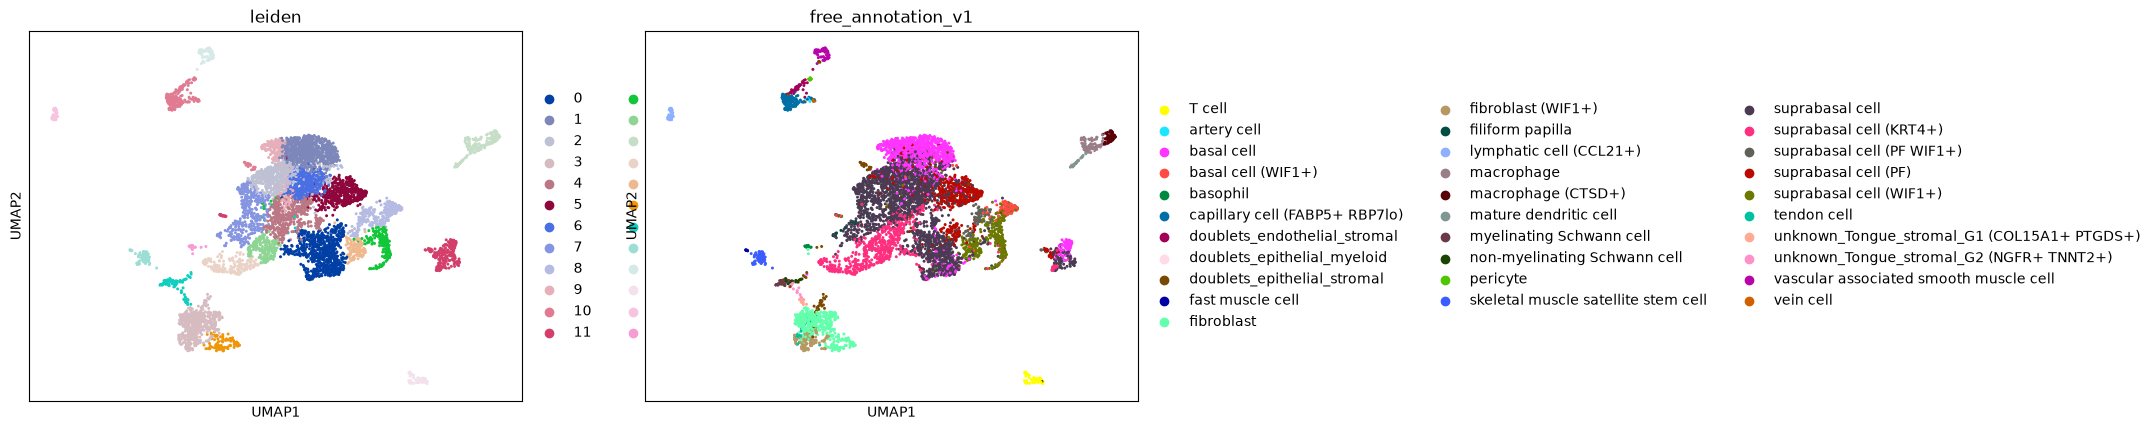

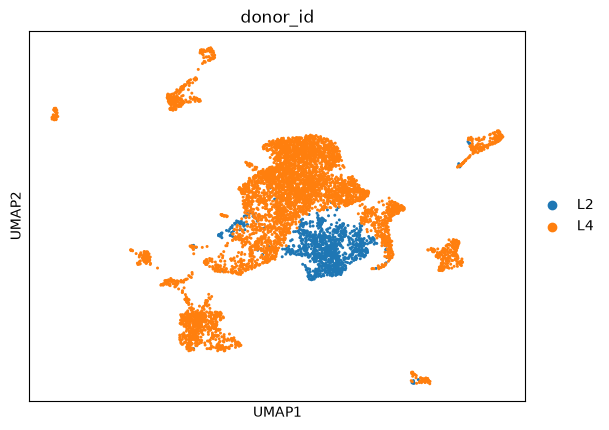

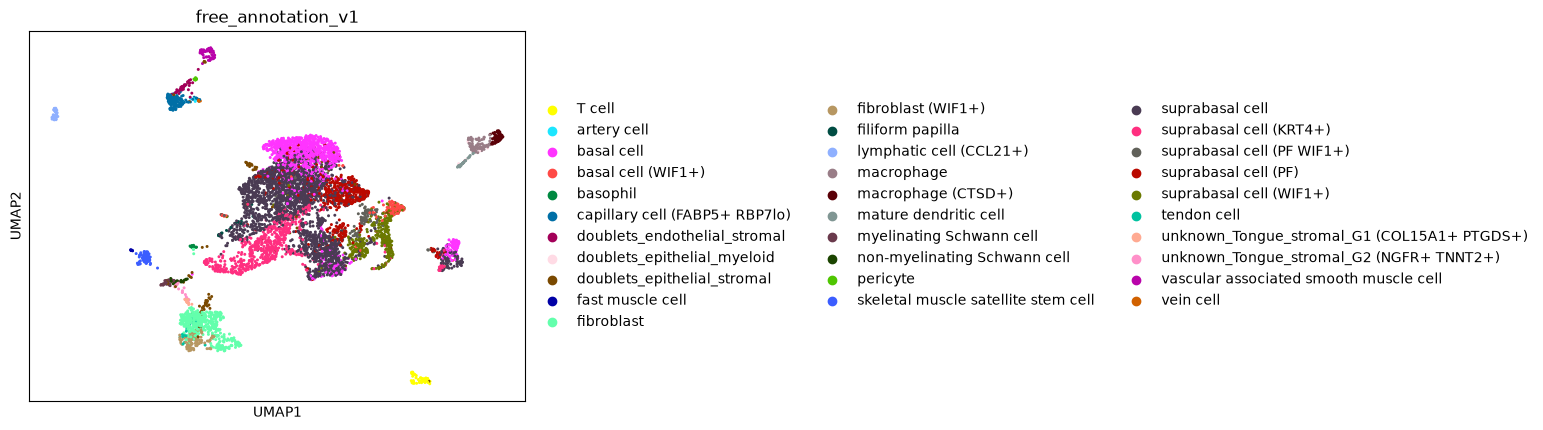

['donor_id', 'age', 'sex', 'disease', 'assay', 'tissue', 'free_annotation_v1', 'leiden', 'cell_type']


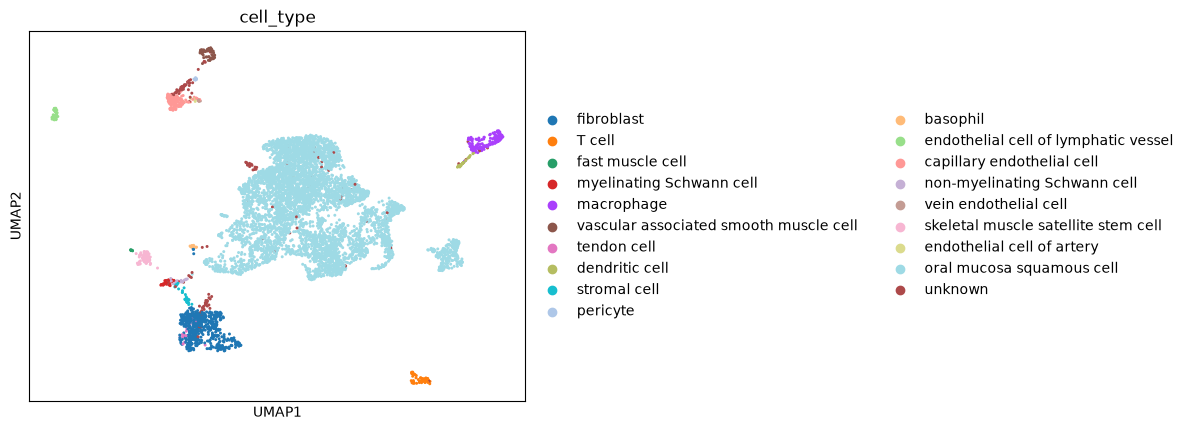

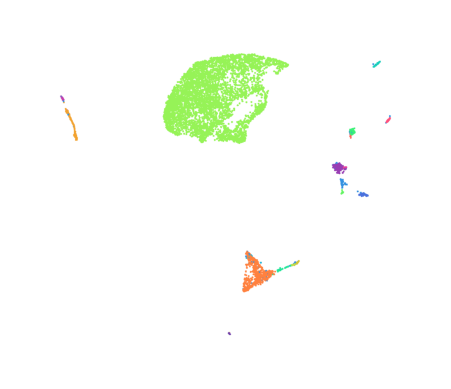

['donor_id', 'age', 'sex', 'disease', 'assay', 'tissue', 'free_annotation_v1', 'leiden', 'cell_type']
['donor_id', 'age', 'sex', 'disease', 'assay', 'tissue', 'free_annotation_v1', 'leiden', 'cell_type']
['nCount_RNA']
['nCount_RNA', 'nFeature_RNA', 'possibly_contaminated_barcode_10x', 'assay_ontology_term_id', 'donor_id', 'age', 'sex_ontology_term_id', 'general_tissue', 'tissue_system', 'tissue_order', 'subtissue', 'compartment_v1', 'cell_ontology_class_v1', 'free_annotation_v1', 'mix_hybrid', 'low_quality', 'dendrogram_annotation_number', 'Mimu_168', 'Mimu_W03', 'Mimu_W04', 'Mimu_180ps', 'Mimu_191', 'Mimu_202', 'Mimu_208', 'Mimu_218', 'Mimu_229ps', 'Mimu_239ps', 'Mimu_249', 'Mimu_DMA', 'Mimu_DMB', 'Mimu_DPA', 'Mimu_DPB', 'Mimu_DQA', 'Mimu_DQB', 'Mimu_DRA', 'Mimu_DRB', 'MHC_C_I', 'MHC_NC_I', 'MHC_all_II', 'nMimu_168', 'nMimu_W03', 'nMimu_W04', 'nMimu_180ps', 'nMimu_191', 'nMimu_202', 'nMimu_208', 'nMimu_218', 'nMimu_229ps', 'nMimu_239ps', 'nMimu_249', 'nMimu_DMA', 'nMimu_DMB', 'nMimu_

In [138]:
import scanpy as sc
import celltypist
from celltypist import models
import anndata as ad
import scanpy as sc

adata = sc.read_h5ad(r"C:\Users\eok33\python_intro\notebooks\data\Tongue.h5ad")
print("adata.X.max():", adata.X.max())
print("adata.raw is None?", adata.raw is None)
if adata.raw is not None:
    print("adata.raw.X.max():", adata.raw.X.max())
adata.X = adata.raw.X.copy()
print(adata.X.max())  # should now show ~300161

adata_original = adata.copy() 

print(adata.obs.columns.tolist())
keep_cols = ['donor_id', 'age', 'sex', 'disease', 'assay', 'tissue', 'free_annotation_v1']
keep_cols = [c for c in keep_cols if c in adata.obs.columns]
adata.obs = adata.obs[keep_cols].copy()


for key in list(adata.obsm.keys()):
    del adata.obsm[key]


print(adata.X.max())
print(adata.obs.columns.tolist())
print(adata.obsm.keys())
print(adata.shape)
print(adata_original.X.max()) 
print(adata_original.obs.columns.tolist()) 
print(adata_original.obs.columns.tolist()) 
print(adata_original.obsm.keys())          
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key='donor_id')

adata.raw = adata  

adata = adata[:, adata.var.highly_variable].copy()

sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata)

sc.tl.leiden(adata, resolution=1.0)
sc.pl.umap(adata, color=['leiden', 'free_annotation_v1'])
sc.pl.umap(adata, color='donor_id')
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon', use_raw=False)
adata.obs.columns
sc.pl.umap(adata, color = "free_annotation_v1")

adata.obs['cell_type'] = adata_original.obs.loc[adata.obs_names, 'cell_type']

print(adata.obs.columns.tolist()) 
sc.pl.umap(adata, color='cell_type')
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(r"C:\Users\eok33\python_intro\notebooks\data\CELLxGENE_umap_emb.png")

plt.imshow(img)
plt.axis('off') 
plt.show()
print(adata.obs.columns.tolist())
qc_cols = ['pct_counts_mt', 'total_counts', 'n_genes_by_counts']
qc_cols = [c for c in qc_cols if c in adata_original.obs.columns]  

for col in qc_cols:
    adata.obs[col] = adata_original.obs.loc[adata.obs_names, col]

print(adata.obs.columns.tolist())  
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
print([c for c in adata_original.obs.columns if 'mt' in c.lower() or 'count' in c.lower()])
print(adata_original.obs.columns.tolist())
qc_cols = ['pct_counts_mt', 'total_counts', 'n_genes_by_counts']
qc_cols = [c for c in qc_cols if c in adata_original.obs.columns]
print("Found these QC cols in adata_original:", qc_cols)

for col in qc_cols:
    adata.obs[col] = adata_original.obs.loc[adata.obs_names, col]

print(adata.obs.columns.tolist())

print(adata_original.obs.columns.tolist())

the online umap (2) vs my umap (1). Whilst the shape differes between the two images, they noth show one large cluster in the centre with multiple smaller clusters surrounding the centre. The main difference is the compactness, my umap shows a more rounded main ckuster while the authors sjhows a more irregular one.  